#### Configuration Paramters

In [ ]:
# Gogle cloud bucket
BUCKET = "centralefs" # Central main bucket

# folder to save processed data file
SAVE_BUCKET = "centralefs/modelfiles"
# under model files there are different folders for different target horizons

# Other configs
FILE_PATH = (
    r"./data/"
    r"File_for_Model_Daily_Volume_Sector_Added_All_pruned_103.parquet"
)
START_DATE = '2012-01-01'       # first date to load from the CSV (used for trimming data, after calcualtion of target returns)
END_DATE   = '2024-12-31'       # last date to load from the CSV (used for trimming data, after calcualtion of target returns)

# Horizon
HORIZON = 7                     # # Number of calendar days ahead the model tries to predict. (here it represents 7 trading days)

CORR_WINDOW     = 60            # rolling window (days) for computing pairwise
                                # stock correlations used to draw graph edges.
                                # Longer window = more stable edges but slower
                                # to react to changing relationships. Here it is used to filter initial days when no correlation is present till 59 rows
###########
TRAIN_START = '2013-01-01'      # training dataset date
TRAIN_END   = '2022-12-31'      # sequences ending on or before this → training set
VALID_START = '2023-03-01'      # sequences ending between VALID_START (with purge)
VALID_END   = '2023-12-31'      # and VALID_END → validation set
TEST_START  = '2024-03-01'      # sequences ending between TEST_START (with purge)
TEST_END    = '2024-12-31'      # and TEST_END → test set
###########

#### Helper Function

In [ ]:
# Feature Transform Function
# ................. Feature Transform .................
# signed log transform
# correlation . pearson
# Spearman rank correlation
# .................

import pandas as pd
import numpy as np

def signed_log1p(x: pd.Series) -> pd.Series:
    """
    Signed log1p transform: preserves sign, and compresses magnitude.
    Standard log1p breaks on negative values. This variant applies log1p to the absolute value and restores the original sign.

    Formula:
        signed_log1p(x) = sign(x) × log(1 + |x|)

    Why I used this?
        Many financial features (OBV, PVT, MACD, turnover) span several orders of magnitude and have negative values. Raw values cause gradient instability in neural networks.
        This transform:
          - Compresses large values without losing small-value detail
          - Keeps negative values negative (unlike standard log)
          - Maps zero to zero (log(1+0) = 0)

    Args:
        x (pd.Series): Input numeric series. Can contain negatives.

    Returns:
        pd.Series: Transformed series, same index as input.

    Example:
        signed_log1p(100)  →  log(101) ≈  4.61
        signed_log1p(-100) → -log(101) ≈ -4.61
        signed_log1p(0)    →  0
    """
    x = x.astype(float)                            # ensures float (avoids integer overflow)
    return np.sign(x) * np.log1p(np.abs(x))        # sign × log(1 + |x|)

# ................. Evaluation of Correlation .................
def safe_corr(x: np.ndarray, y: np.ndarray) -> float:
    """
    Pearson correlation with a safety check for constant arrays.
    Standard np.corrcoef returns NaN (or raises) when one array has zero variance (all values identical). This wrapper returns NaN gracefully instead of crashing.
    Used in daily IC computation: if all stocks have the same predicted mid-point on a given day, IC is undefined....So I return NaN and skip.

    Args:
        x, y (np.ndarray): Arrays to correlate. Must be same length.

    Returns:
        float: Pearson correlation, or NaN if either array is constant.
    """
    x, y = np.asarray(x), np.asarray(y)
    if np.std(x) < 1e-12 or np.std(y) < 1e-12:                                  # constant array check with std-deviation
        return np.nan
    return np.corrcoef(x, y)[0, 1]                                              # standard Pearson correlation


def safe_spearman(x: np.ndarray, y: np.ndarray) -> float:
    """
    Spearman rank correlation with a safety check for constant arrays.

    Spearman IC is used as the primary metric for evaluating ranking ability of stocks.
    It is robust to outliers and monotone transforms, making it standard in quantitative finance for signal evaluation.

    A daily Spearman IC of 0.05 is considered weak but real signal. An ICIR (mean IC / std IC) above 0.5 indicates a usable signal.

    Args:
        x, y (np.ndarray): Arrays to correlate. Must be same length.

    Returns:
        float: Spearman correlation, or NaN if either array is constant.
    """
    x, y = np.asarray(x), np.asarray(y)
    if np.std(x) < 1e-12 or np.std(y) < 1e-12:    # constant array check
        return np.nan
    return spearmanr(x, y).correlation              # rank correlation from scipy

def apply_volume_adjusted_target(df, window=HORIZON, baseline=22):
    """
    Calculates a conviction-weighted target: (Forward 7-day Return) * tanh(Relative Volume).
    Logic: Punishes low-volume 'fluke' moves and normalizes targets for ML.
    """
    # 1. Sort to ensure time-series integrity
    df = df.sort_values(['Symbol', 'Date']).copy()

    # 2. Define calculation per group (Symbol)
    def get_conviction(group):
        # Forward average volume during the prediction window (t+1 to t+7)
        fwd_vol = group['volume'].rolling(window=window).mean().shift(-window)

        # Historical baseline volume (last 22 days)
        hist_vol_ma = group['volume'].rolling(window=baseline).mean()

        # Relative Volume Ratio (Conviction Score)
        v_rel = fwd_vol / hist_vol_ma.replace(0, np.nan)

        # Apply tanh scaling to the return
        # tanh(v_rel) ensures the multiplier stays between 0 and 1
        return np.tanh(v_rel.fillna(0))

    # 3. Applying
    df['vol_multiplier'] = df.groupby('Symbol', group_keys=False).apply(get_conviction)
    # 4. Scaling
    df['target_vol_adj'] = df[TARGET_COL] * df['vol_multiplier']
    # 5. Dropping
    df.drop(columns=['vol_multiplier'], inplace=True)

    return df
# ................. Sanity Check .................
# # smoke-test to confirm all functions work before training.

# if __name__ == "__main__" or True:

#     # test signed_log1p
#     _s = pd.Series([100.0, -100.0, 0.0])
#     _t = signed_log1p(_s)
#     assert _t[0] > 0 and _t[1] < 0 and _t[2] == 0, "signed_log1p sign preservation failed"

#     # test safe_corr with constant array
#     assert np.isnan(safe_corr(np.ones(5), np.array([1,2,3,4,5]))), \
#         "safe_corr should return NaN for constant array"

#     print("The helper functions passed sanity checks.")

#### Load & Import Libraries

In [ ]:
# %%capture
# Capture is magic command and used to hide outputs from this cell
################################################## Google Storage Buckets for Data ############################################
# Create the local folders first so gsutil has a target
!mkdir -p src data

# Sync folders specifically
!gsutil -m cp -r gs://{BUCKET}/src/* ./src/                                        # classes written for various operations
!gsutil -m cp -r gs://{BUCKET}/datapruned/* ./data/                                # main data file

# Adding src folder to Python path
import sys
import os
sys.path.append(os.path.join(os.getcwd(), 'src'))
print("Files synced")

# Importing classes

from data_processor_v4_Commented_4          import DataProcessorV2
# DataProcessorV2  : reads the CSV, computes targets, applies feature transforms,
#                    returns master_df and feature_cols

# Standard scientific computing
import numpy as np                          # numerical arrays and math operations
import pandas as pd                         # dataframes for tabular data manipulation

# Scipy — scientific utilities
from scipy.stats import spearmanr           # rank correlation (used in IC calculations)
from scipy.stats import skew, kurtosis      # distribution shape metrics (used in EDA)

# Plotting
import matplotlib.pyplot as plt             # standard plotting library
import matplotlib.gridspec as gridspec      # flexible subplot layouts
import seaborn as sns                       # statistical visualisation (heatmaps etc.)

# Utilities
import warnings                             # suppress non-critical warnings
warnings.filterwarnings("ignore")           # keep output clean during EDA and training

# Date handling
from datetime import datetime               # used to timestamp saved graph sequence files

# Display Settings
pd.set_option('display.max_columns', 200)   # show all columns when printing a dataframe
pd.set_option('display.width', 160)         # wider display to avoid column wrapping

# Sanity Checks
# Confirm versions
print("=" * 50)
print("NumPy version     :", np.__version__)
print("Pandas version    :", pd.__version__)
print("=" * 50)
print("  CONFIGURATION SUMMARY")
print("=" * 50)
print(f"  FILE_PATH        : ...{FILE_PATH[-75:]}")
print(f"  Date range       : {START_DATE} → {END_DATE}")
print(f"  Horizon          : {HORIZON} day(s)")
print(f"  Corr window      : {CORR_WINDOW} day(s)")
print(f"  Train            : {TRAIN_START} → {TRAIN_END}")
print(f"  Valid            : {VALID_START} → {VALID_END}")
print(f"  Test             : {TEST_START} → {TEST_END}")
print("=" * 50)

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://centralefs/src/__init__.py...
Copying gs://centralefs/src/engine_v5_unified.py...
Copying gs://centralefs/src/data_processor_v3_Commented_3.py...
Copying gs://centralefs/src/engine_v5_unified1_old-no-margin.py...
Copying gs://centralefs/src/graph_builder_v4.py...
Copying gs://centralefs/src/models_v5_unified.py...
Copying gs://centralefs/src/engine_v5_unified1.py...
Copying gs://centralefs/src/data_processor_v4_Commented_4.py...
Copying gs://centralefs/src/graph_builder_v3.py...
Copying gs://centralefs/src/dataset_v4.py...
Copying gs://centralefs/src/graph_builder_v3_1.py...
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please r

In [ ]:
# data processor class to add additional features
dp = DataProcessorV2(
    parquet_path   = FILE_PATH,          # path to CSV
    start_date     = START_DATE,        # '2012-01-01' - must include warmup year
    end_date       = END_DATE,          # '2024-12-31' - set above
    target_horizon = HORIZON,           # days ahead to predict - set above
    corr_window    = CORR_WINDOW,       # rolling window for correlation - set above
)

# calling the instance
master_df, feature_cols, metadata = dp.build_master_df(feature_exclude=None)

# Print Statements
print(f"master_df shape    : {master_df.shape}")
print(f"Initial features   : {len(feature_cols)}")            # numeric columns not in hard exclude (so doesn't incldue symbol, date, sector)
print(f"Date range loaded  : {master_df['Date'].min().date()} → {master_df['Date'].max().date()}")
print(f"Stocks loaded      : {master_df['Symbol'].nunique()}")
print(f"Horizon for Target : {metadata}")
TARGET_COL = metadata["target_col"]
print(f"Target column      : {TARGET_COL}")
print("Data loaded successfully.")
print(f"Range of target     : Max {master_df[TARGET_COL].max()} | Min {master_df[TARGET_COL].min()}")

master_df shape    : (329806, 145)
Initial features   : 123
Date range loaded  : 2012-01-02 → 2024-12-31
Stocks loaded      : 103
Horizon for Target : {'target_col': 'target_ret_7_d', 'target_horizon': 7}
Target column      : target_ret_7_d
Data loaded successfully.
Range of target     : Max 0.9309968476809624 | Min -1.7674625674072728


In [ ]:
# a copy
master_df_full = master_df.copy()

In [ ]:
# Aplpying the funcion ... apply_volume_adjusted_target.... horizon = HORIZON, baseline = last 22 days
"""
Calculates a conviction-weighted target: (Forward 7-day Return) * tanh(Relative Volume).
Logic: Punishes low-volume 'fluke' moves and normalizes targets for ML.
"""
master_df_full = apply_volume_adjusted_target(master_df_full)

# New target column defined
TARGET_COL = 'target_vol_adj'

In [ ]:
master_df_full.describe()

,Date,close,high,low,open,volume,nse_turnoverinr,nse_numtrades,nse_pctdailyqtytraded_filled,RSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,ROC_10,STOCHk_14_3_3,STOCHd_14_3_3,STOCHh_14_3_3,CCI_14_0.015,SMA_20,SMA_50,SMA_200,EMA_9,EMA_21,EMA_50,EMA_200,ADX_14,ADXR_14_2,DMP_14,DMN_14,PSARl_0.02_0.2,PSARs_0.02_0.2,PSARaf_0.02_0.2,PSARr_0.02_0.2,AROOND_14,AROONU_14,AROONOSC_14,SUPERT_7_3.0,SUPERTd_7_3.0,SUPERTl_7_3.0,SUPERTs_7_3.0,BBL_20_2.0_2.0,BBM_20_2.0_2.0,BBU_20_2.0_2.0,BBB_20_2.0_2.0,BBP_20_2.0_2.0,KCLe_20_2,KCBe_20_2,KCUe_20_2,DCL_20_20,DCM_20_20,DCU_20_20,ATRr_14,STDEV_30,OBV,PVT,MFI_14,CMF_20,AD,VWAP_D,EFI_13,ISA_9,ISB_26,ITS_9,IKS_26,ICS_26,"Net Profit Margin, (%)","Gross Margin, Percent",Current Ratio,Quick Ratio,"Operating Profit Margin, Percent",Revenue Per Share,P/E (Daily Time Series Ratio),Enterprise Value To EBITDA (Daily Time Series Ratio),Enterprise Value To EBIT (Daily Time Series Ratio),Net Debt To EBITDA (Daily Time Series Ratio),Total Debt To EBITDA (Daily Time Series Ratio),Price To Book Value Per Share (Daily Time Series Ratio),Price To Tangible Book Value Per Share (Daily Time Series Ratio),Forward Price To Book Value Per Share (Daily Time Series Ratio),Price To Cash Flow Per Share (Daily Time Series Ratio),Price To Sales Per Share (Daily Time Series Ratio),Enterprise Value To Sales (Daily Time Series Ratio),Turnover,Total Revenue,"ROA Total Assets, Percent",ROE Common Equity %,ROE Total Equity %,"Revenue Per Share, 3 Yr CAGR","Tot Revenue, 3 Yr CAGR","Cost of Revenue, 3 Yr CAGR",Asset Turnover,Fixed Asset Turnover,Interest Coverage Ratio,"Interest Coverage Ratio, Period-Period Diff","Asset Turnover, Prd-Prd Diff","Fixed Asset Turnover, Period-Period Diff","Gross Margin, Percent_flag",Current Ratio_flag,Quick Ratio_flag,P/E (Daily Time Series Ratio)_flag,Enterprise Value To EBITDA (Daily Time Series Ratio)_flag,Enterprise Value To EBIT (Daily Time Series Ratio)_flag,Net Debt To EBITDA (Daily Time Series Ratio)_flag,Total Debt To EBITDA (Daily Time Series Ratio)_flag,Forward Price To Book Value Per Share (Daily Time Series Ratio)_flag,Price To Cash Flow Per Share (Daily Time Series Ratio)_flag,ROE Total Equity %_flag,"Revenue Per Share, 3 Yr CAGR_flag","Tot Revenue, 3 Yr CAGR_flag","Cost of Revenue, 3 Yr CAGR_flag",Asset Turnover_flag,Fixed Asset Turnover_flag,Interest Coverage Ratio_flag,"Interest Coverage Ratio, Period-Period Diff_flag","Asset Turnover, Prd-Prd Diff_flag","Fixed Asset Turnover, Period-Period Diff_flag",bulk_buy_w,bulk_sell_w,bulk_net_w,bulk_flag,bulk_buy_signal,bulk_sell_signal,bulk_net_signal,bulk_intensity_signal,bulk_direction_ratio_signal,buy_count,sell_count,report_lag_days,qty_per_trade,log_volume,volvol_30,volvol_90,vol_z_30,vol_rank_30,vol_prank_30,sector_idx,log_close,log_open,ret_1d,target_ret_7_d,ret_hist_count,eligible_corr,target_vol_adj
count,329806,329806.000000,329806.000000,329806.000000,329806.000000,3.298060e+05,3.298060e+05,3.298060e+05,329806.000000,328364.000000,326407.000000,326407.000000,326407.000000,328776.000000,328055.000000,328055.000000,328055.000000,328467.000000,327849.000000,324759.000000,309309.000000,328982.000000,327746.000000,324759.000000,309309.000000,327025.000000,326819.000000,328467.000000,328467.000000,175875.000000,153828.000000,329806.000000,329806.000000,328364.000000,328364.000000,328364.000000,329085.000000,329085.000000,189900.000000,139185.000000,327849.000000,327849.000000,327849.000000,327849.000000,327849.000000,327746.000000,327849.000000,327746.000000,327849.000000,327849.000000,327849.000000,328364.000000,326819.000000,3.298060e+05,3.297030e+05,3.283640e+05,327849.000000,3.298060e+05,329763.000000,3.284670e+05,324656.000000,321978.000000,328982.000000,327231.000000,329806.000000,277690.000000,271261.000000,252509.000000,252509.000000,277869.000000,277869.000000,327307.000000,329806.000000,328942.000000,234202.000000,319562.000000,329806.000000,329806.000000,324189.000000,323821.000000,329806.000000,329806.000000,2.721700e+05,3.29806

In [ ]:
# update the split
master_df_full.loc[master_df_full['Date'] < '2023-01-01', 'split'] = 'train'

In [ ]:
# check split data
len(master_df_full[(master_df_full['split'] == 'train') & (master_df_full['Symbol'] == 'ADANIENT.NS')]), len(master_df_full[(master_df_full['split'] == 'valid') & (master_df_full['Symbol'] == 'ADANIENT.NS')]), len(master_df_full[(master_df_full['split'] == 'test') & (master_df_full['Symbol'] == 'ADANIENT.NS')]),

(2711, 245, 246)

Lower Quantile: -0.2468
Upper Quantile: 0.2486


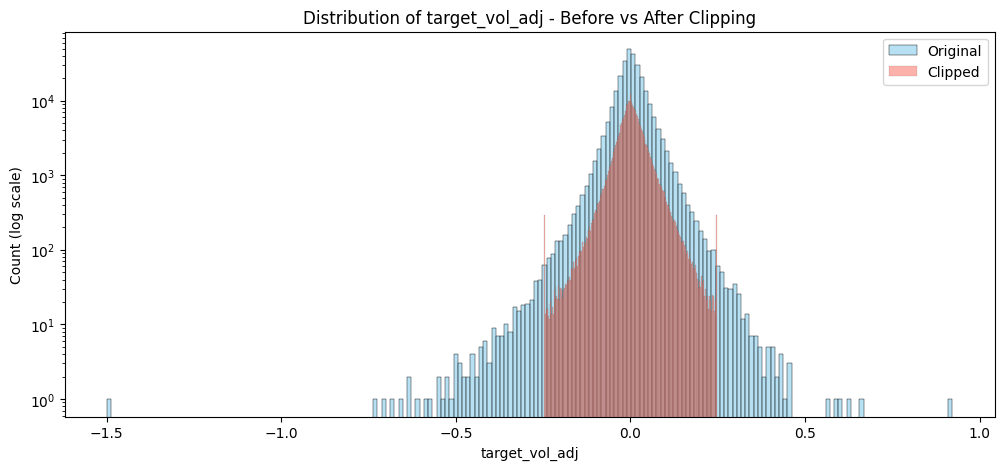

'\nLower Quantile: -0.2509\nUpper Quantile: 0.2536\n'

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mask for train data
train_mask = master_df_full['split'] == 'train'
train_target = master_df_full.loc[train_mask, TARGET_COL]

# Compute clipping thresholds from train
lower, upper = train_target.quantile([0.001, 0.999])
print(f'Lower Quantile: {lower:.4f}')
print(f'Upper Quantile: {upper:.4f}')

# Clip target
train_target_clipped = train_target.clip(lower, upper)

# Plot before and after
plt.figure(figsize=(12,5))

sns.histplot(train_target, bins=200, color='skyblue', label='Original', alpha=0.6)
sns.histplot(train_target_clipped, bins=200, color='salmon', label='Clipped', alpha=0.6)

plt.title(f"Distribution of {TARGET_COL} - Before vs After Clipping")
plt.xlabel(TARGET_COL)
plt.ylabel("Count (log scale)")
plt.yscale('log')  # log scale to see the tail clearly
plt.legend()
plt.show()

In [ ]:
# Cliping Target based on Training data only to smooth outliers .. TARGET_COL = 'target_vol_adj'

master_df_full[TARGET_COL] = master_df_full[TARGET_COL].clip(lower, upper)

# Quick check
print(master_df_full[TARGET_COL].describe())

count    329806.000000
mean          0.003660
std           0.044767
min          -0.246806
25%          -0.017458
50%           0.001337
75%           0.023504
max           0.248608
Name: target_vol_adj, dtype: float64


In [ ]:
# feature engineering
# Feature eng for avg turnover per trade ..................................... because nse_numtrades & nse_turnoverinr were highlight correlated > 0.9
master_df_full['turnover_per_trade'] = np.where(                                                          # np.where(condition, x, y)
    master_df_full["nse_numtrades"] != 0,                             # np.where(condition, value_if_true, value_if_false)
    master_df_full["nse_turnoverinr"] / master_df_full["nse_numtrades"],
    np.nan
   )

# further feature engineering due to correlations between features
master_df_full['SMA_Ratio1'] = np.where(
    master_df_full["SMA_50"] != 0,
    master_df_full["SMA_20"] / master_df_full["SMA_50"],
    np.nan
)

master_df_full['SMA_Ratio2'] = np.where(
    master_df_full["SMA_200"] != 0,
    master_df_full["SMA_50"] / master_df_full["SMA_200"],
    np.nan
)

# Ichimoku indicator featrue engineered to reduce correlation
master_df_full['ISB_26-ISA_9'] = master_df_full["ISB_26"] / master_df_full["ISA_9"]
master_df_full['IKS_26-ITS_9'] = master_df_full["IKS_26"] / master_df_full["ITS_9"]

# 'Revenue-to-Cost Ratio'
master_df_full['Revenue_to_Cost_Ratio'] = np.where(
    master_df_full["Cost of Revenue, 3 Yr CAGR"] != 0,
    master_df_full["Revenue Per Share, 3 Yr CAGR"] / master_df_full["Cost of Revenue, 3 Yr CAGR"],
    np.nan
)
# Flag modification for the ratio
rev_flag = master_df_full["Revenue Per Share, 3 Yr CAGR_flag"]
cost_flag = master_df_full["Cost of Revenue, 3 Yr CAGR_flag"]

master_df_full["Revenue_to_Cost_Ratio_flag"] = (
    (rev_flag == 1) |
    (cost_flag == 1) |
    (master_df_full["Cost of Revenue, 3 Yr CAGR"] == 0)
).astype(int)

# High - Low
master_df_full['H-L'] = (master_df_full["high"]) - (master_df_full["low"])

# PVT/OBV (as they are highly correlated), ratio compares the sensitivity of price-adjusted volume to raw volume accumulation.
master_df_full['PVT_OBV Ratio'] = np.where(
    master_df_full["OBV"] != 0,
    master_df_full["PVT"] / master_df_full["OBV"],
    np.nan
)

# check on stocks stats
stats = master_df_full.groupby("Symbol")["Date"].agg(['count', 'min', 'max'])

# Checking if all symbols have the exact same stats
unique_stats = stats.drop_duplicates()

if len(unique_stats) == 1:
    # Everything is identical
    row_count = unique_stats.iloc[0]['count']
    start_dt = unique_stats.iloc[0]['min']
    end_dt = unique_stats.iloc[0]['max']
    num_stocks = len(stats)

    print(f"All {num_stocks} stocks are perfectly aligned.")
    print(f"Rows per stock: {row_count} | Range: {start_dt.date()} to {end_dt.date()}")
else:
    # There are discrepancies
    print(f"Warning: Data is NOT aligned. Found {len(unique_stats)} different configurations.")
    print("\nBreakdown of different row counts/ranges found:")
    print(stats.value_counts().reset_index(name='number_of_stocks'))

    print("\nFirst 5 stocks for reference:")
    print(stats.head())
# deleting unused variables later
del stats
del unique_stats

All 103 stocks are perfectly aligned.
Rows per stock: 3202 | Range: 2012-01-02 to 2024-12-31


In [ ]:
# Drop Unwanted Columns & Define Exclusion Set
# DROP    — physically delete from the dataframe (no longer needed)
# EXCLUDE — keep in the dataframe but never pass to the model as
#           input features (needed for targets, graph construction, split logic)
# NOTE on ret_1d:
#   Listed in EXCLUDE (leakage as a model input) but intentionally NOT listed in DROP. ret_1d must remain in master_df_full because GraphBuilderV2._pivot_returns() uses it to build the rolling
#   correlation matrix for graph edges. I fill its NaN separately later on.

DROP = [                             # feature selection using correlation in target for multicollinearlity features
    # internal
    #'target_ret_7_d',                # kept for sharpe
    'volvol_30',
    'Net Profit Margin, (%)', # not important as per IC ratio
    'EFI_13', # kept RSI_14
    'Revenue Per Share, 3 Yr CAGR',
    'Cost of Revenue, 3 Yr CAGR',
    'MACD_12_26_9', # removed as RSI_!4 is kept .75+ correlated overall
    'ROC_10',  # removed and kept RSI_14
    'AROONU_14',
    'AROOND_14',                    # -0.006607
    'STOCHk_14_3_3', # kept CCI
    'OBV',
    'PVT',
    "SMA_200",
#    "Price To Book Value Per Share (Daily Time Series Ratio)",       # 0.006785
    'Price To Tangible Book Value Per Share (Daily Time Series Ratio)',
    "bulk_buy_w", "bulk_sell_w",
    "bulk_buy_signal", "bulk_sell_signal",
    'close',
    'vol_z_30',                             # -0.011812
    'vol_rank_30',                          # -0.011848 .. kept prank
    'SMA_50',
    'SMA_20',
    'ICS_26',           # leakage parameter so dropped
    'qty_per_trade',
    'volume',           # raw volume — encoded in transformed versions, -0.019949 (have log_volume)
    'log_close',        # log of close price — not a predictive feature
    'ret_hist_count',   # internal DataProcessorV2 counter
    'eligible_corr',    # internal flag used only during correlation computation
    'report_lag_days',  # all 0 for these 120 stocks
    # feature engineerered
    "nse_turnoverinr",  # used in feature eng for turnover_per_trade, -0.028107, turnover_per_trade =-0.013007
    "nse_numtrades",    # used in feature eng for turnover_per_trade, -0.029925
    # Highly correlated
    "EMA_9",            # high correlation with SMA
    #"ADXR_14_2",        # high correlation with SMA................. 0.008153
    "ADX_14",
    "BBL_20_2.0_2.0",   # high correlation with SMA
    #"BBB_20_2.0_2.0",   # high correlation with SMA................ 0.006534
    'BBM_20_2.0_2.0',   # high correlation with
    "STOCHd_14_3_3",    # high correlation with STOCKhk
    "ATRr_14",          # high correlation with SMA
    #"MFI_14",           # high correlation with RSI ........ 0.01359
    'high',
    'low',
    'Turnover',           # -0.026948
    'open',
    'Total Revenue',      # -0.022725
    # Cluster 1
    "buy_count", "sell_count", "VWAP_D",
    # Cluster 3
    "EMA_21", "BBU_20_2.0_2.0", "DCU_20_20", "KCUe_20_2", "KCLe_20_2", "DCL_20_20",
    "EMA_50",
    "ISA_9", "ITS_9", "IKS_26", "ISB_26",        # IKS_26-ITS_9 = 0.007281
    "EMA_200",
    "STDEV_30",
    "DMN_14",
    "DMP_14",
    # Cluster 5
    "Forward Price To Book Value Per Share (Daily Time Series Ratio)",
    "ROE Total Equity %",
    "Enterprise Value To EBIT (Daily Time Series Ratio)",          # ....0.013501.... kept EBITDA for certain reasonas to usage of metric
    "bulk_intensity_signal",
    "MACDh_12_26_9", "MACDs_12_26_9",
    "BBP_20_2.0_2.0",                 # 0.008017
    'KCBe_20_2',
    'DCM_20_20',
    'log_open',
    "Current Ratio",    # high correlation with Quick Ratio
    "Current Ratio_flag",
    "Operating Profit Margin, Percent",                   # not important as per IC ratio
    "Total Debt To EBITDA (Daily Time Series Ratio)",     # Net Debt kept        # -0.00755
    "Total Debt To EBITDA (Daily Time Series Ratio)_flag",
    "Price To Sales Per Share (Daily Time Series Ratio)", # EV to sales kept
    "ROA Total Assets, Percent",       # 0.009612         # highly correlated wth others
    #1"Tot Revenue, 3 Yr CAGR",                             # Rev per share kept
    #1"Tot Revenue, 3 Yr CAGR_flag",

    #1"Forward Price To Book Value Per Share (Daily Time Series Ratio)_flag",
    #1"ROE Total Equity %_flag",
    'CCI_14_0.015', # kept BBP_20_2.0_2.0 as it has more correlatio nwith target 0.008017, dropped that too to keep RSI_14
    #1"Enterprise Value To EBIT (Daily Time Series Ratio)_flag",
    # "Price To Book Value Per Share (Daily Time Series Ratio)",
    # "H-L",
    #1"Revenue Per Share, 3 Yr CAGR_flag",      # dropped as ratio was calucalted anf flag computed
    #1"Cost of Revenue, 3 Yr CAGR_flag",        # dropped as ratio was calucalted anf flag computed
    "Quick Ratio",
    "Quick Ratio_flag",
    "Net Debt To EBITDA (Daily Time Series Ratio)",
    "Net Debt To EBITDA (Daily Time Series Ratio)_flag",
    "Revenue Per Share",
    "Gross Margin, Percent",
    "Gross Margin, Percent_flag",
    'P/E (Daily Time Series Ratio)_flag',
    'Enterprise Value To EBITDA (Daily Time Series Ratio)_flag',
    'Enterprise Value To EBIT (Daily Time Series Ratio)_flag',
    'Total Debt To EBITDA (Daily Time Series Ratio)_flag',
    'Forward Price To Book Value Per Share (Daily Time Series Ratio)_flag',
    'Price To Cash Flow Per Share (Daily Time Series Ratio)_flag',
    'ROE Total Equity %_flag',
    'Revenue Per Share, 3 Yr CAGR_flag',
    'Tot Revenue, 3 Yr CAGR_flag',
    'Cost of Revenue, 3 Yr CAGR_flag',
    'Asset Turnover_flag',
    'Fixed Asset Turnover_flag',
    #'Interest Coverage Ratio_flag',
    #'Interest Coverage Ratio, Period-Period Diff_flag',
    'Asset Turnover, Prd-Prd Diff_flag',
    'Fixed Asset Turnover, Period-Period Diff_flag',
    'Revenue_to_Cost_Ratio_flag'
]

SPARSE_TA_DROP = [
    c for c in master_df_full.columns
    if 'PSAR' in c or 'SUPERT' in c
]

# adding more columns to be dropped
DROP.extend(SPARSE_TA_DROP)

# dropping cols from df
master_df_full = master_df_full.drop(columns=DROP, errors="ignore").copy()

# count of dropped columns
n_dropped = len([c for c in DROP if c not in master_df_full.columns])

# prints
print(f"Dropped columns             : {DROP}")
print(f"Count of Columns Dropped    : {n_dropped}")
print(f"master_df_full shape        : {master_df_full.shape}")
print(f"master_df_columns           : {master_df_full.columns}")

Dropped columns             : ['volvol_30', 'Net Profit Margin, (%)', 'EFI_13', 'Revenue Per Share, 3 Yr CAGR', 'Cost of Revenue, 3 Yr CAGR', 'MACD_12_26_9', 'ROC_10', 'AROONU_14', 'AROOND_14', 'STOCHk_14_3_3', 'OBV', 'PVT', 'SMA_200', 'Price To Tangible Book Value Per Share (Daily Time Series Ratio)', 'bulk_buy_w', 'bulk_sell_w', 'bulk_buy_signal', 'bulk_sell_signal', 'close', 'vol_z_30', 'vol_rank_30', 'SMA_50', 'SMA_20', 'ICS_26', 'qty_per_trade', 'volume', 'log_close', 'ret_hist_count', 'eligible_corr', 'report_lag_days', 'nse_turnoverinr', 'nse_numtrades', 'EMA_9', 'ADX_14', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'STOCHd_14_3_3', 'ATRr_14', 'high', 'low', 'Turnover', 'open', 'Total Revenue', 'buy_count', 'sell_count', 'VWAP_D', 'EMA_21', 'BBU_20_2.0_2.0', 'DCU_20_20', 'KCUe_20_2', 'KCLe_20_2', 'DCL_20_20', 'EMA_50', 'ISA_9', 'ITS_9', 'IKS_26', 'ISB_26', 'EMA_200', 'STDEV_30', 'DMN_14', 'DMP_14', 'Forward Price To Book Value Per Share (Daily Time Series Ratio)', 'ROE Total Equity %', 

In [ ]:
# further column drops
master_df_full = master_df_full.drop(columns = ['nse_pctdailyqtytraded_filled', 'ADXR_14_2', 'BBB_20_2.0_2.0', 'MFI_14', 'CMF_20', 'Tot Revenue, 3 Yr CAGR', 'Asset Turnover', 'Fixed Asset Turnover', 'Interest Coverage Ratio, Period-Period Diff',
       'Asset Turnover, Prd-Prd Diff', 'Interest Coverage Ratio, Period-Period Diff_flag', 'bulk_net_w', 'bulk_flag', 'bulk_net_signal', 'bulk_direction_ratio_signal', 'log_volume',
       'volvol_90', 'SMA_Ratio2',
       'ISB_26-ISA_9', 'IKS_26-ITS_9', 'Revenue_to_Cost_Ratio', 'PVT_OBV Ratio'])

In [ ]:
##############################################################################################################
# Signed Log-trasnformations

# columns not to transform
NO_TRANSFORM = set([
    # Identifiers / metadata
    "Date", "Symbol", "Sector", "sector_idx", "split",
    # Target and leakage
    "ret_1d", TARGET_COL,
    "target_ret_7_d",       # for sharpe ratio validation
    "log_close",
    "ret_hist_count", "eligible_corr",
    # Already bounded / pre-scaled
    "CMF_20",
    "log_volume",
    "vol_z_30",
    "vol_prank_30",
    "vol_rank_30",
    # Bulk binary / categorical signals
    "bulk_buy_w", "bulk_sell_w", "bulk_net_w",
    "bulk_buy_signal", "bulk_sell_signal",
    "bulk_net_signal", "bulk_direction_ratio_signal", "bulk_flag",
]) | set([c for c in master_df_full.columns if c.endswith("_flag")])

# numeric columns
num_cols       = master_df_full.select_dtypes(include=[np.number]).columns.tolist()
transform_cols = [c for c in num_cols if c not in NO_TRANSFORM]

# applying signed log transform function
for c in transform_cols:
    master_df_full[c] = signed_log1p(master_df_full[c])

# prints
print(f"Columns transformed   : {len(transform_cols)}")
print(f"                : {transform_cols} ...")
print(f"NOT transformed       : {[c for c in num_cols if c in NO_TRANSFORM]}")

##############################################################################################################

# Feature break

# non feature columns (used for identifications)
NON_FEATURE_COLS = set([
    "Date", "Symbol", "Sector", "sector_idx", "split",      # Identifiers / metadata
    "ret_1d",                                               # Target and leakage # Leakage — today's return cannot predict itself
    TARGET_COL, "target_ret_7_d",                           # Target
    # Safety nets (already dropped but listed for clarity)
    "log_close", "ret_hist_count", "eligible_corr",         # also close is already transformed so no need for log_close
])

# main feature columns
feature_cols_new = [
    c for c in master_df_full.columns
    if c not in NON_FEATURE_COLS
    and pd.api.types.is_numeric_dtype(master_df_full[c])
]

# flag features
flag_features = [c for c in feature_cols_new
                 if c.endswith("_flag") or c == "bulk_flag"]
# continuous flat features
cont_features = [c for c in feature_cols_new if c not in flag_features] + [TARGET_COL]
# prints
print(f"\nOld feature count     : {len(feature_cols)}")
print(f"New feature count     : {len(feature_cols_new)}")
print(f"  Continuous          : {len(cont_features)}")
print(f"  Flag features       : {len(flag_features)}")
print(f"\nFlag features (model input, no transform):")
for f in flag_features:
    print(f"  {f}")

##############################################################################################################

# Flag Check

# --- Step 1: Group by Symbol and count total rows and missing values ---
flag_check = master_df_full.groupby('Symbol')['Interest Coverage Ratio'].agg(
    total_rows='size',            # total rows for the stock
    non_missing='count'           # counts non-NaN values
).reset_index()

# Compute actual number of missing values
flag_check['num_missing'] = flag_check['total_rows'] - flag_check['non_missing']

# --- Step 2: Determine what the flag should be ---
# Rule: 0 if all missing, 1 if at least one value exists
flag_check['flag_should_be'] = flag_check.apply(
    lambda row: 0 if row['num_missing'] == row['total_rows'] else 1,
    axis=1
)

# --- Step 3: Identify stocks that should have flag = 0 ---
stocks_flag0 = flag_check[flag_check['flag_should_be'] == 0]

# --- Step 4: Output ---
print("Summary of Interest Coverage Ratio by stock:")
print(flag_check)

print("\nStocks with flag = 0 (Interest Coverage Ratio missing for all time points):")
print(stocks_flag0)

print("\nTotal number of stocks with flag = 0:", len(stocks_flag0))
print("Total number of stocks with flag = 1:", len(flag_check) - len(stocks_flag0))

##############################################################################################################

Columns transformed   : 15
                : ['RSI_14', 'STOCHh_14_3_3', 'AROONOSC_14', 'AD', 'P/E (Daily Time Series Ratio)', 'Enterprise Value To EBITDA (Daily Time Series Ratio)', 'Price To Book Value Per Share (Daily Time Series Ratio)', 'Price To Cash Flow Per Share (Daily Time Series Ratio)', 'Enterprise Value To Sales (Daily Time Series Ratio)', 'ROE Common Equity %', 'Interest Coverage Ratio', 'Fixed Asset Turnover, Period-Period Diff', 'turnover_per_trade', 'SMA_Ratio1', 'H-L'] ...
NOT transformed       : ['Interest Coverage Ratio_flag', 'vol_prank_30', 'sector_idx', 'ret_1d', 'target_ret_7_d', 'target_vol_adj']

Old feature count     : 123
New feature count     : 17
  Continuous          : 17
  Flag features       : 1

Flag features (model input, no transform):
  Interest Coverage Ratio_flag
Summary of Interest Coverage Ratio by stock:
            Symbol  total_rows  non_missing  num_missing  flag_should_be
0      ADANIENT.NS        3202         3202            0             

In [ ]:
# status check
master_df_full.describe()

,Date,RSI_14,STOCHh_14_3_3,AROONOSC_14,AD,P/E (Daily Time Series Ratio),Enterprise Value To EBITDA (Daily Time Series Ratio),Price To Book Value Per Share (Daily Time Series Ratio),Price To Cash Flow Per Share (Daily Time Series Ratio),Enterprise Value To Sales (Daily Time Series Ratio),ROE Common Equity %,Interest Coverage Ratio,"Fixed Asset Turnover, Period-Period Diff",Interest Coverage Ratio_flag,vol_prank_30,sector_idx,ret_1d,target_ret_7_d,target_vol_adj,turnover_per_trade,SMA_Ratio1,H-L
count,329806,328364.000000,328055.000000,328364.000000,329806.000000,327307.000000,329806.000000,329806.000000,323821.000000,329806.000000,329806.000000,298307.000000,329806.000000,329806.000000,328879.000000,329806.000000,329703.000000,329806.000000,329806.000000,329806.000000,324759.000000,329806.000000
mean,2018-07-04 13:13:18.251093248,3.954816,-0.010949,0.483293,-7.412668,3.331956,2.890019,1.586272,3.044933,1.482621,2.543730,3.043475,0.032574,0.980583,0.510683,8.592233,0.000759,0.003467,0.003660,10.096558,0.698391,2.421137
min,2012-01-02 00:00:00,1.941884,-3.457300,-4.615121,-24.678596,0.706535,0.610834,-6.963545,0.188938,0.134356,-5.580086,-5.548514,-4.871337,0.000000,0.033333,0.000000,-0.490194,-1.767463,-0.246806,5.222391,0.460273,0.000000
25%,2015-04-09 00:00:00,3.810138,-1.707334,-3.931826,-18.701092,2.758493,2.369023,1.001211,2.341633,0.982699,2.382407,1.468755,-0.248460,1.000000,0.233333,5.000000,-0.010090,-0.027032,-0.017458,9.730433,0.683630,1.384160
50%,2018-07-03 12:00:00,3.981197,-0.063813,3.110336,-16.806752,3.288986,2.833290,1.514987,3.067206,1.414718,2.873358,2.604360,0.022036,1.000000,0.500000,9.000000,0.000286,0.002776,0.001337,10.158089,0.698550,2.309430
75%,2021-10-04 00:00:00,4.130433,1.695105,4.178773,14.657383,3.853503,3.335743,2.071505,3.714131,1.915081,3.224287,4.232830,0.310777,1.000000,0.766667,13.000000,0.011089,0.033856,0.023504,10.520931,0.713627,3.227335
max,2024-12-31 00:00:00,4.572984,3.424056,4.615121,21.775087,8.519029,7.046972,4.560957,8.984878,5.349559,4.822371,12.463830,4.353014,1.000000,1.000000,16.000000,0.336472,0.930997,0.248608,14.539821,0.897162,8.405287
std,NaN,0.243785,1.817816,3.954335,15.999613,0.916289,0.751877,0.851011,1.006288,0.692435,1.446531,2.142041,0.779535,0.137987,0.297060,4.609910,0.021433,0.055686,0.044767,0.651439,0.025830,1.319641


In [ ]:
# print(master_df_full.groupby('Symbol')['AD'].agg(['mean', 'std', 'min', 'max']))

In [ ]:
# Winsorizing at 1% using percentiles based on training data
# winsorizng taking care of stock specific and common features

# Step 1 — for scale-dependent features, z-score PER STOCK using train history
# This removes the "Reliance is always bigger than small-cap" bias

STOCK_SPECIFIC_FEATURES = ['H-L', 'turnover_per_trade', 'AD']

train_mask = (
    (master_df_full['split'] == 'train') &
    (master_df_full['Date'] >= '2013-01-01')
)

# Compute per-stock mean and std from training period only
stock_stats = (
    master_df_full[train_mask]
    .groupby('Symbol')[STOCK_SPECIFIC_FEATURES]
    .agg(['mean', 'std'])
)

# Apply to all splits using each stock's own training stats
for col in STOCK_SPECIFIC_FEATURES:
    col_mean = master_df_full['Symbol'].map(stock_stats[col]['mean'])
    col_std  = master_df_full['Symbol'].map(stock_stats[col]['std'])
    col_std  = col_std.replace(0, 1.0).fillna(1.0)
    master_df_full[col] = (master_df_full[col] - col_mean) / col_std


# Step 2 — for cross-sectionally comparable features,
# winsorize and z-score across the whole training pool

CROSS_SECTIONAL_FEATURES = [
    'RSI_14', 'STOCHh_14_3_3', 'AROONOSC_14',
    'P/E (Daily Time Series Ratio)',
    'Enterprise Value To EBITDA (Daily Time Series Ratio)',
    'Price To Book Value Per Share (Daily Time Series Ratio)',
    'Price To Cash Flow Per Share (Daily Time Series Ratio)',
    'Enterprise Value To Sales (Daily Time Series Ratio)',
    'ROE Common Equity %', 'Interest Coverage Ratio',
    'Fixed Asset Turnover, Period-Period Diff',
    'SMA_Ratio1'
]

clip_bounds = {}
feat_stats  = {}

for col in CROSS_SECTIONAL_FEATURES:
    lo = master_df_full.loc[train_mask, col].quantile(0.001)
    hi = master_df_full.loc[train_mask, col].quantile(0.999)
    clip_bounds[col] = (lo, hi)
    master_df_full[col] = master_df_full[col].clip(lo, hi)

    mu  = master_df_full.loc[train_mask, col].mean()
    std = master_df_full.loc[train_mask, col].std()
    std = std if std > 1e-8 else 1.0
    feat_stats[col] = (mu, std)
    master_df_full[col] = (master_df_full[col] - mu) / std


In [ ]:
# status check
master_df_full.describe()

,Date,RSI_14,STOCHh_14_3_3,AROONOSC_14,AD,P/E (Daily Time Series Ratio),Enterprise Value To EBITDA (Daily Time Series Ratio),Price To Book Value Per Share (Daily Time Series Ratio),Price To Cash Flow Per Share (Daily Time Series Ratio),Enterprise Value To Sales (Daily Time Series Ratio),ROE Common Equity %,Interest Coverage Ratio,"Fixed Asset Turnover, Period-Period Diff",Interest Coverage Ratio_flag,vol_prank_30,sector_idx,ret_1d,target_ret_7_d,target_vol_adj,turnover_per_trade,SMA_Ratio1,H-L
count,329806,328364.000000,328055.000000,328364.000000,329806.000000,327307.000000,329806.000000,329806.000000,323821.000000,329806.000000,329806.000000,298307.000000,329806.000000,329806.000000,328879.000000,329806.000000,329703.000000,329806.000000,329806.000000,329806.000000,324759.000000,329806.000000
mean,2018-07-04 13:13:18.251093248,0.037865,0.000283,0.019118,0.299570,0.017000,0.026401,0.033825,0.025027,0.034871,0.020301,-0.007859,0.062696,0.980583,0.510683,8.592233,0.000759,0.003467,0.003660,0.022098,0.025119,0.131262
min,2012-01-02 00:00:00,-4.415340,-1.770118,-1.267197,-78.646925,-2.447885,-2.347998,-5.788281,-2.606733,-1.916615,-5.579608,-3.854342,-5.748978,0.000000,0.033333,0.000000,-0.490194,-1.767463,-0.246806,-5.858943,-5.508235,-7.942402
25%,2015-04-09 00:00:00,-0.557204,-0.931206,-1.094803,-0.608391,-0.604475,-0.678387,-0.693926,-0.667516,-0.708591,-0.090876,-0.712834,-0.290789,1.000000,0.233333,5.000000,-0.010090,-0.027032,-0.017458,-0.652363,-0.533465,-0.721642
50%,2018-07-03 12:00:00,0.145706,-0.028747,0.681913,-0.183211,-0.029742,-0.049998,-0.057953,0.047144,-0.065739,0.247548,-0.204444,0.049356,1.000000,0.500000,9.000000,0.000286,0.002776,0.001337,0.075501,0.030844,0.034729
75%,2021-10-04 00:00:00,0.758940,0.937076,0.951477,0.619515,0.581853,0.630075,0.630928,0.684338,0.678812,0.489451,0.524594,0.412443,1.000000,0.766667,13.000000,0.011089,0.033856,0.023504,0.738208,0.601088,0.870262
max,2024-12-31 00:00:00,2.173191,1.789074,1.061566,92.746366,5.579023,4.953268,3.552758,5.364565,5.258550,1.555358,4.209468,5.253847,1.000000,1.000000,16.000000,0.336472,0.930997,0.248608,8.305490,4.114392,12.801363
std,NaN,0.998150,0.998054,0.997667,3.702809,0.992210,1.014954,1.027048,0.989679,1.028001,0.997086,0.958954,0.977629,0.137987,0.297060,4.609910,0.021433,0.055686,0.044767,1.052394,0.969430,1.223110


In [ ]:
# NaN Diagnostic — Before F-Fill ................................................. 2013 Onwards

# temporary testdf for nan check ... deleted later on after evaluation
testdf = master_df_full[master_df_full['Date'] >= pd.to_datetime('2013-01-01')].copy()

# count of NaN
nan_counts  = testdf[feature_cols_new].isnull().sum()
nan_counts  = nan_counts[nan_counts > 0].sort_values(ascending=False)   # sorted to display
total_nan   = nan_counts.sum()                                          # total nan
total_cells = testdf[feature_cols_new].size                             # size of df
total_rows  = len(testdf)                                               # total rows

print("__" * 65)
print("  NaN Diagnostics -- Before F-Fill ----- 2013 onwards")
print("__" * 65)
print(f"  Total feature NaN : {total_nan:,}  ({total_nan/total_cells:.2%})")
print(f"  Cols with NaN     : {len(nan_counts)} / {len(feature_cols_new)}")
print()
print(f"  {'Column':<55} {'NaN':>8}  {'%':>7}  Strategy")        # col names
print(f"  {'_'*90}")
# loop ... for counts
for col, n in nan_counts.items():                                # for each one
    pct = n / total_rows * 100                                   # % nan
    if col.endswith("_flag") or col == "bulk_flag":              # flag columns
        strat = "0-fill (flag)"
    elif pct > 5:
        strat = "ffill->0 (High NaN)"
    else:
        strat = "ffill->0 (Low NaN)"
    print(f"  {col:<55} {n:>8,}  {pct:>6.2f}%  {strat}")

if 'ret_1d' in testdf.columns:
    ret1d_nan = testdf['ret_1d'].isnull().sum()
    print(f"\n  ret_1d (graph edge col, not a feature): "
          f"{ret1d_nan:,} NaN  <- Will Fix Later (if 0, no need to fix)")
print("__" * 65)

del testdf

__________________________________________________________________________________________________________________________________
  NaN Diagnostics -- Before F-Fill ----- 2013 onwards
__________________________________________________________________________________________________________________________________
  Total feature NaN : 32,433  (0.63%)
  Cols with NaN     : 3 / 17

  Column                                                       NaN        %  Strategy
  __________________________________________________________________________________________
  Interest Coverage Ratio                                   26,505    8.70%  ffill->0 (High NaN)
  Price To Cash Flow Per Share (Daily Time Series Ratio)     3,805    1.25%  ffill->0 (Low NaN)
  P/E (Daily Time Series Ratio)                              2,123    0.70%  ffill->0 (Low NaN)

  ret_1d (graph edge col, not a feature): 0 NaN  <- Will Fix Later (if 0, no need to fix)
_________________________________________________________

  FEATURE CORRELATION (TIME-AWARE)
  Features analysed       : 17
  Rows used              : 261,534
  High corr pairs (>0.75) : 1

  Top high-correlation pairs:
  Feature A                                Feature B                                  Corr
  ----------------------------------------------------------------------------------------
  Enterprise Value To EBITDA (Daily Time Series Ratio) Price To Cash Flow Per Share (Daily Time Series Ratio) +0.755


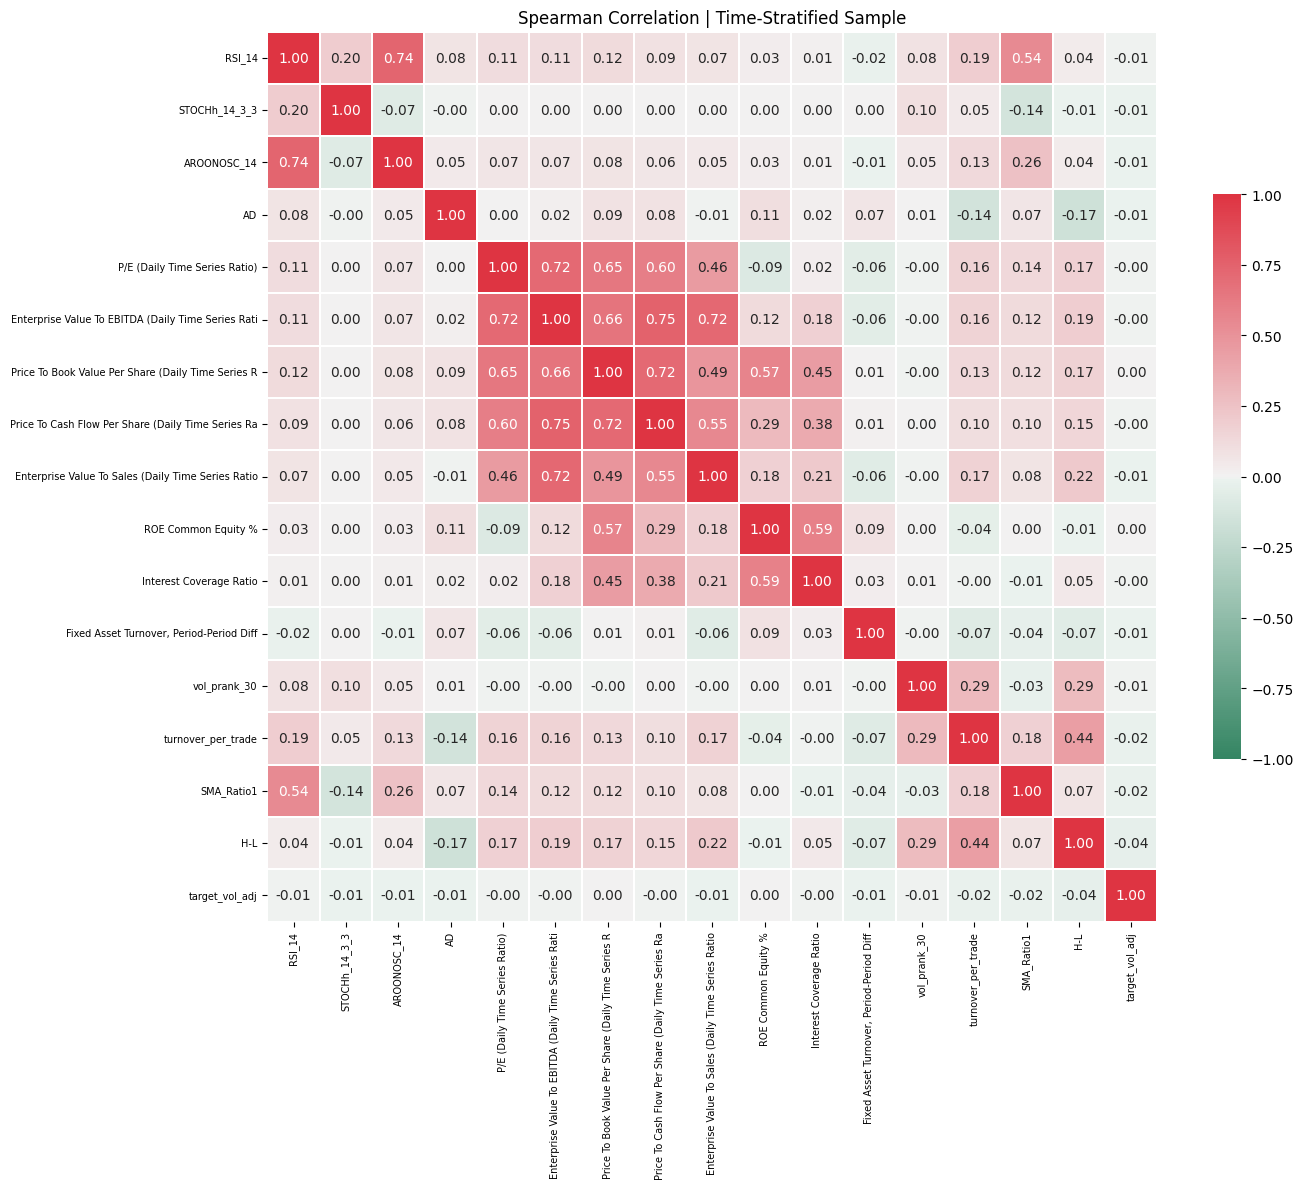


Final feature count: 17


<Figure size 640x480 with 0 Axes>

In [ ]:
# ============================================================
# 1. STRATIFIED TIME SAMPLING (to prevent any regime bias)..................... Only on Training Data
# ============================================================
def stratified_time_sample(df, features, date_col, n_per_period=1000, freq="M"):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    sampled = (
        df.sort_values(date_col)
          .groupby(pd.Grouper(key=date_col, freq=freq))
          .apply(lambda x: x.sample(min(len(x), n_per_period), random_state=42))
          .reset_index(drop=True)
    )

    return sampled[features]


# ============================================================
# 2. MAIN FUNCTION: CORRELATION
# ============================================================
def eda_feature_corr_timeaware(
    master_df_full,
    cont_features,
    date_col="date",
    sample_per_month=1000,
    corr_threshold=0.75,
    use_stratified_sampling=True
):

    # -------- sampling --------
    if use_stratified_sampling:
        df = stratified_time_sample(
            master_df_full,
            cont_features,
            date_col=date_col,
            n_per_period=sample_per_month,
            freq="M"
        )
    else:
        df = master_df_full[cont_features].sample(
            min(50000, len(master_df_full)), random_state=42
        )

    print("=" * 60)
    print("  FEATURE CORRELATION (TIME-AWARE)")
    print("=" * 60)
    print(f"  Features analysed       : {len(cont_features)}")
    print(f"  Rows used              : {len(df):,}")

    # -------- correlation --------
    corr = df.corr(method="spearman")

    # -------- find high-corr pairs (for reporting only) --------
    pairs = []
    for i in range(len(cont_features)):
        for j in range(i + 1, len(cont_features)):
            c = corr.iloc[i, j]
            if abs(c) >= corr_threshold:
                pairs.append((cont_features[i], cont_features[j], c))

    pairs.sort(key=lambda x: abs(x[2]), reverse=True)

    print(f"  High corr pairs (>{corr_threshold}) : {len(pairs)}")

    if pairs:
        print("\n  Top high-correlation pairs:")
        print(f"  {'Feature A':<40} {'Feature B':<40} {'Corr':>6}")
        print(f"  {'-'*88}")
        for a, b, c in pairs[:20]:
            print(f"  {a:<40} {b:<40} {c:>+6.3f}")

    # -------- heatmap --------
    fig, ax = plt.subplots(figsize=(max(14, len(cont_features)*0.4),
                                     max(12, len(cont_features)*0.4)))

    short = [c[:50] for c in cont_features]
    cmap = sns.diverging_palette(150, 10, s=80, l=50, as_cmap=True)

    sns.heatmap(
        corr,
        xticklabels=short,
        yticklabels=short,
        cmap=cmap,
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.3,
        cbar_kws={"shrink": 0.6},
        annot=True,
        fmt=".2f",
        ax=ax,
        )

    ax.set_title("Spearman Correlation | Time-Stratified Sample", fontsize=12)
    plt.xticks(fontsize=7, rotation=90)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.show()

    plt.savefig("fig1_eda_1_feature_corr.svg", format='svg', dpi=300)

    return corr, pairs


# ============================================================
# 3. USAGE
# ============================================================

# ONLY TRAINING DATA (correct practice)
train_df = master_df_full[master_df_full['split'] == 'train']

corr, pairs = eda_feature_corr_timeaware(
    master_df_full=train_df,
    cont_features=cont_features,
    date_col="Date",              # Date
    sample_per_month=2000,
    corr_threshold=0.75,
    use_stratified_sampling=True
)

# -------- final feature list --------
final_features = cont_features.copy()

print("\nFinal feature count:", len(final_features))

#### Target vs Feature Correlation ..Cross Sectional over the stocks

In [ ]:
master_df_full.columns

Index(['Symbol', 'Date', 'RSI_14', 'STOCHh_14_3_3', 'AROONOSC_14', 'AD', 'P/E (Daily Time Series Ratio)',
       'Enterprise Value To EBITDA (Daily Time Series Ratio)', 'Price To Book Value Per Share (Daily Time Series Ratio)',
       'Price To Cash Flow Per Share (Daily Time Series Ratio)', 'Enterprise Value To Sales (Daily Time Series Ratio)', 'ROE Common Equity %',
       'Interest Coverage Ratio', 'Fixed Asset Turnover, Period-Period Diff', 'Interest Coverage Ratio_flag', 'vol_prank_30', 'Sector', 'sector_idx', 'ret_1d',
       'target_ret_7_d', 'split', 'target_vol_adj', 'turnover_per_trade', 'SMA_Ratio1', 'H-L'],
      dtype='object')

Mean correlation across symbols:
Price To Book Value Per Share (Daily Time Series Ratio)   -0.069958
Enterprise Value To Sales (Daily Time Series Ratio)       -0.066281
Price To Cash Flow Per Share (Daily Time Series Ratio)    -0.064982
Enterprise Value To EBITDA (Daily Time Series Ratio)      -0.056254
P/E (Daily Time Series Ratio)                             -0.046380
H-L                                                       -0.034889
AD                                                        -0.031345
SMA_Ratio1                                                -0.027076
Interest Coverage Ratio                                   -0.026286
turnover_per_trade                                        -0.019303
AROONOSC_14                                               -0.016425
RSI_14                                                    -0.016097
ROE Common Equity %                                       -0.015615
Fixed Asset Turnover, Period-Period Diff                  -0.012643
STOCHh_14_3_3  

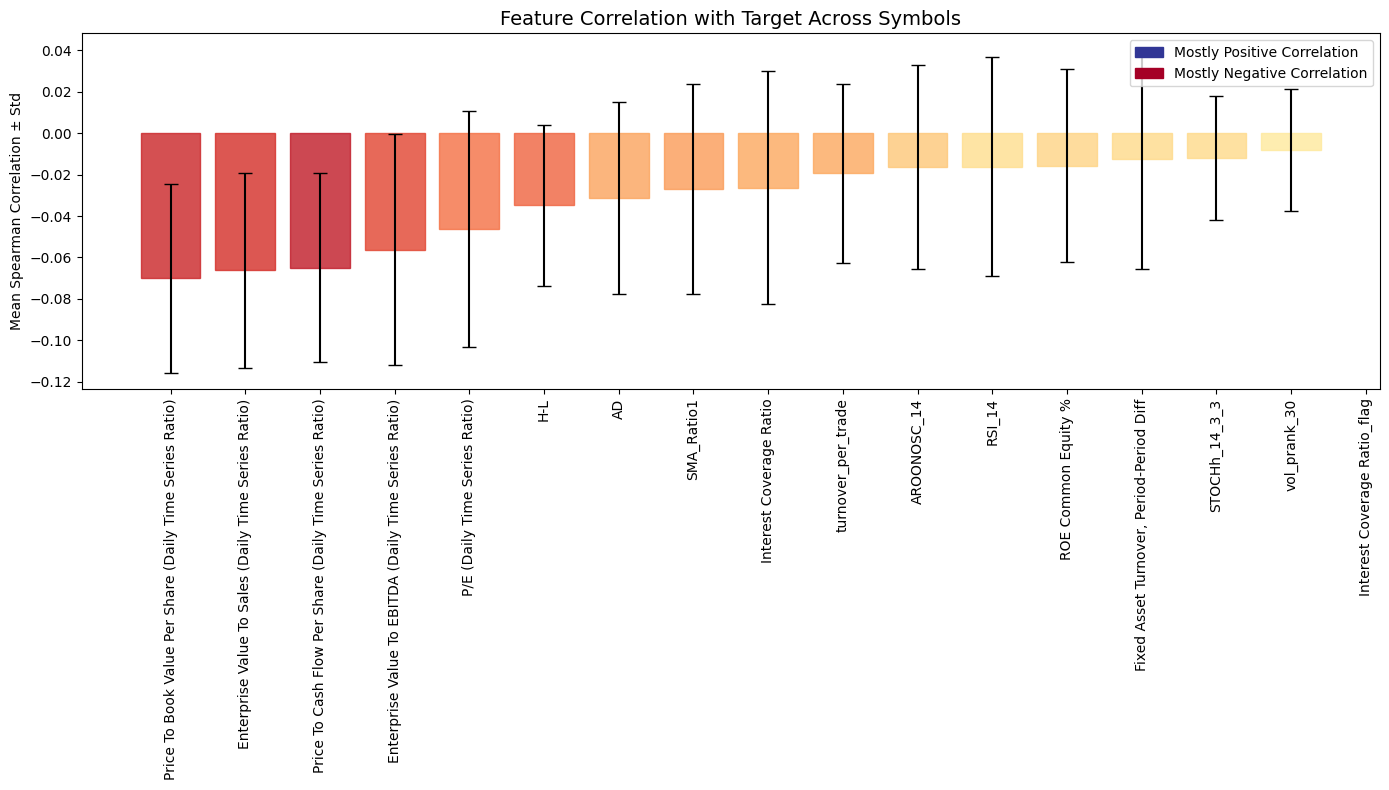

In [ ]:
# For each symbol, compute correlation between features and target.................... | ..... Only On Training Dataset
# using its own time series (already aligned) .........................................................................

symbol_corrs = []
for sym in master_df_full['Symbol'].unique():
    df_sym = master_df_full[(master_df_full['split']=='train') & (master_df_full['Symbol']==sym)]
    if len(df_sym) > 200:  # require minimum observations
        corr_sym = df_sym[feature_cols_new + [TARGET_COL]].corr(method='spearman')[TARGET_COL].drop(TARGET_COL)
        symbol_corrs.append(corr_sym)

# Convert to DataFrame
symbol_corrs_df = pd.DataFrame(symbol_corrs)

# Compute mean, std, and fraction positive (if not already done)
mean_corr = symbol_corrs_df.mean()
median_corr = symbol_corrs_df.median()
std_corr = symbol_corrs_df.std()
frac_pos = (symbol_corrs_df > 0).mean()

# distribution across symbols
print("Mean correlation across symbols:")
print(mean_corr.sort_values(key=abs, ascending=False).head(40))
print("\nStandard deviation across symbols:")
print(std_corr.sort_values(ascending=False).head(40))

print("\nMedian correlation across symbols:")
print(median_corr.sort_values(key=abs, ascending=False).head(40))

print("\nFraction of symbols with positive correlation:")
frac_posp = frac_pos.sort_values(ascending=False)
print(frac_posp.head(40))

# Sort by mean correlation magnitude for better visibility
order = mean_corr.abs().sort_values(ascending=False).index

# Plot
plt.figure(figsize=(14, 8))
bars = plt.bar(
    x=np.arange(len(mean_corr)),
    height=mean_corr[order],
    yerr=std_corr[order],
    capsize=5,
    color=sns.color_palette("coolwarm", n_colors=len(mean_corr)),
    alpha=0.8
)

# Color code by fraction of positive correlations
for bar, f in zip(bars, frac_pos[order]):
    bar.set_color(plt.cm.RdYlBu(f))  # fraction -> color (blue=0, red=1)

plt.xticks(np.arange(len(mean_corr)), order, rotation=90, fontsize=10)
plt.ylabel("Mean Spearman Correlation ± Std")
plt.title("Feature Correlation with Target Across Symbols", fontsize=14)

# color legend
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color=plt.cm.RdYlBu(1.0), label='Mostly Positive Correlation')
blue_patch = mpatches.Patch(color=plt.cm.RdYlBu(0.0), label='Mostly Negative Correlation')
plt.legend(handles=[red_patch, blue_patch], loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# # Using symbol_corrs_df
# mean_corr = symbol_corrs_df.mean()
# frac_pos = (symbol_corrs_df > 0).mean()
# std_corr = symbol_corrs_df.std()

# Rule thresholds
mean_threshold = 0.010
consistency_threshold = 0.60   # 60% of symbols have same sign

consistent_neg = (frac_pos <= (1 - consistency_threshold)) & (mean_corr <= -mean_threshold)
consistent_pos = (frac_pos >= consistency_threshold) & (mean_corr >= mean_threshold)

good_features = list(mean_corr[consistent_neg | consistent_pos].index)
print("Features to keep:", good_features)

len(good_features)

Features to keep: ['RSI_14', 'STOCHh_14_3_3', 'AROONOSC_14', 'AD', 'P/E (Daily Time Series Ratio)', 'Enterprise Value To EBITDA (Daily Time Series Ratio)', 'Price To Book Value Per Share (Daily Time Series Ratio)', 'Price To Cash Flow Per Share (Daily Time Series Ratio)', 'Enterprise Value To Sales (Daily Time Series Ratio)', 'ROE Common Equity %', 'Interest Coverage Ratio', 'Fixed Asset Turnover, Period-Period Diff', 'turnover_per_trade', 'SMA_Ratio1', 'H-L']


15

#### NaN Fill

In [ ]:
# ############ NaN Fill - Flag Columns ######################
# 0-fill only . NaN in a flag means data was structurally absent.
# Correct interpretation: 0 = data not available.
# NOT ffilled flags as the absence on one date does not imply the same availability state on the next date. | There is no gap to be filled though | Cna even skip but kept for robustness

print("Filling NaN in flag features...")

print(f"NaN in flags before fill {master_df_full[flag_features].isnull().sum().sum()}")

master_df_full[flag_features] = master_df_full[flag_features].fillna(0)

nan_after_flags = master_df_full[flag_features].isnull().sum().sum()
unique_vals     = sorted(master_df_full[flag_features].stack().unique())
print(f"  NaN after fill  : {nan_after_flags}  "
      f"{'ok' if nan_after_flags == 0 else 'PROBLEM'}")
print(f"  Unique values   : {unique_vals}  (expected [0.0, 1.0])")

print("~"*65)

# .......... NaN Fill ... ret_1d  ..........
# ret_1d is NOT a model feature but GraphBuilderV2 uses it to build the 90-day rolling correlation matrix for graph edges.
# Any NaN causes the graph builder to skip the ENTIRE date window for all stocks -> missing sequences.
# ret_1d  : 0 = no price move (correct for suspension days)

print("Cleaning ret_1d for model ...")

print(f"ret_1d NaN before fill: {master_df_full['ret_1d'].isnull().sum()} (1 each for {len(master_df_full['Symbol'].unique())} stocks")

if 'ret_1d' in master_df_full.columns:
    # fill with 0 because a missing return usually implies a non-trading day or the very first row of a stock's history.
    master_df_full['ret_1d'] = master_df_full['ret_1d'].fillna(0)

print(f"ret_1d NaN after fill: {master_df_full['ret_1d'].isnull().sum()} (Set to 0)")

Filling NaN in flag features...
NaN in flags before fill 0
  NaN after fill  : 0  ok
  Unique values   : [np.float64(0.0), np.float64(1.0)]  (expected [0.0, 1.0])
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Cleaning ret_1d for model ...
ret_1d NaN before fill: 103 (1 each for 103 stocks
ret_1d NaN after fill: 0 (Set to 0)


#### Data Sanity Checks

In [ ]:
# .............. Sanity Checks ..............

print("~~" * 60)
print("Data Sanity Checks")
print("~~" * 60)

checks = []

# 1. Zero NaN in all features
nan_final = master_df_full[master_df_full['Date']>='2013-01-01'][feature_cols_new].isnull().sum().sum()
checks.append(("NaN in features (01-01-2013 to 31-12-2024 (fundamentals only with flags))",        nan_final == 0,
               nan_final))

# 2. Zero NaN in ret_1d
ret1d_nan = master_df_full['ret_1d'].isnull().sum()
checks.append(("NaN in ret_1d",          ret1d_nan == 0,
               ret1d_nan))

# 3. Balanced panel
rows_per = master_df_full.groupby("Symbol").size()
balanced = rows_per.min() == rows_per.max()
checks.append(("Panel balanced",         balanced,
               f"{rows_per.min()} / {rows_per.max()}"))

# 4. No graph-only cols leaked into features
graph_only = {'ret_1d', 'sector_idx', 'target_ret_7d',
              'log_close', 'ret_hist_count', 'eligible_corr'}                   # these are already droppped for this study 'log_close', 'ret_hist_count', 'eligible_corr'
leaked = [c for c in feature_cols_new if c in graph_only]
checks.append(("Leakage in features",    len(leaked) == 0,
               leaked or "none"))

# 5. Target not in features
checks.append(("Target in features",     TARGET_COL not in feature_cols_new,
               ""))

# 6. ret_1d not in features
checks.append(("ret_1d in features",     'ret_1d' not in feature_cols_new,
               ""))

# 7. Flag values are binary
flag_vals = set(master_df_full[flag_features].stack().unique())
flag_ok   = flag_vals.issubset({0, 1, 0.0, 1.0})
checks.append(("Flag values binary",     flag_ok,
               sorted(flag_vals)))

# 8. vol_* columns present as features
vol_features = [c for c in feature_cols_new
                if c.startswith('vol_') or c == 'log_volume'
                or c in ('volvol_30', 'volvol_90')]
checks.append(("vol_* cols in features", len(vol_features) > 0,
               vol_features))

for name, passed, detail in checks:
    status = "ok     " if passed else "PROBLEM"
    print(f"  {status}  {name:<30}  {detail}")

print()
print(f"  Stocks        : {master_df_full['Symbol'].nunique()}")
print(f"  Trading days  : {master_df_full['Date'].nunique()}")
print(f"  Total rows    : {len(master_df_full):,}")
print(f"  Features      : {len(feature_cols_new)}")
print(f"    Continuous  : {len(cont_features)}")
print(f"    Flags       : {len(flag_features)}")
print(f"  Target col    : {TARGET_COL}")
print("~~" * 60)

print("Columns with NaNs in Dataset")
print(
 (master_df_full[master_df_full['Date']>='2013-01-01'].isnull().sum().loc[lambda x: x > 0])
)
print("Flag Features")
print(flag_features)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Data Sanity Checks
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
  PROBLEM  NaN in features (01-01-2013 to 31-12-2024 (fundamentals only with flags))  32433
  ok       NaN in ret_1d                   0
  ok       Panel balanced                  3202 / 3202
  ok       Leakage in features             none
  ok       Target in features              
  ok       ret_1d in features              
  ok       Flag values binary              [np.float64(0.0), np.float64(1.0)]
  ok       vol_* cols in features          ['vol_prank_30']

  Stocks        : 103
  Trading days  : 3202
  Total rows    : 329,806
  Features      : 17
    Continuous  : 17
    Flags       : 1
  Target col    : target_vol_adj
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [ ]:
#### The NaN are due to missing Interest coverage ratio for starting time, and for the 2 stocks, which was handled with NaN filling.

#### Total Null Report

In [ ]:
# Null Report from master_df_full
# master_df_full.columns
df = master_df_full.copy()

# CONIFG
NULL_THRESHOLD_COL  = 10   # % nulls to flag a column as "problematic"
NULL_THRESHOLD_STOCK = 50  # % nulls across features to flag a stock
# LOAD
print(f"\n Null Analysis Report")
print(f"   Shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print(f"   Symbols: {df['Symbol'].nunique():,}   |   Date range: {df['Date'].min()} → {df['Date'].max()}")

# ── DROP FLAG COLUMNS ─────────────────────────────────────────────────────────
flag_cols = [c for c in df.columns if c.endswith("_flag")]
df_main = df.drop(columns=flag_cols)
print(f"\n Flag columns excluded ({len(flag_cols)}): {flag_cols[:5]}{'...' if len(flag_cols)>5 else ''}")

# Identity / non-feature columns
id_cols = ["Symbol", "Date", "split", "Sector", "sector_idx"]
feature_cols = [c for c in df_main.columns if c not in id_cols]

# ═══════════════════════════════════════════════════════════════════════════════
# COLUMN-LEVEL NULL ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════
col_null = (df_main[feature_cols]
            .isnull()
            .mean()
            .mul(100)
            .round(2)
            .sort_values(ascending=False)
            .reset_index())
col_null.columns = ["Column", "Null_Pct"]
col_null["Null_Count"] = (col_null["Null_Pct"] / 100 * len(df_main)).round(0).astype(int)
col_null["Status"] = col_null["Null_Pct"].apply(
    lambda x: "Critical (>80%)" if x > 80
    else ("High (50-80%)" if x > 50
    else ("Moderate (10-50%)" if x > 10
    else "OK (<10%)"))
)

#col_null.to_csv("/mnt/user-data/outputs/1_column_null_analysis.csv", index=False)
print("\n" + "═"*60)
print("1. Column Null Analysis (Null > 1%)")
print("═"*60)
print(col_null[col_null["Null_Pct"] > 1.0].to_string(index=False))

# del df # not neded !
# ═══════════════════════════════════════════════════════════════════════════════
# STOCK-LEVEL NULL ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════
stock_null = (df_main.groupby("Symbol")[feature_cols]
              .apply(lambda g: g.isnull().mean().mean() * 100)
              .round(2)
              .reset_index())
stock_null.columns = ["Symbol", "Avg_Null_Pct"]

# Merge sector info (first occurrence per symbol)
sector_map = df_main.drop_duplicates("Symbol")[["Symbol","Sector"]].copy()
stock_null = stock_null.merge(sector_map, on="Symbol", how="left")
stock_null = stock_null.sort_values("Avg_Null_Pct", ascending=False)
stock_null["Status"] = stock_null["Avg_Null_Pct"].apply(
    lambda x: "Severe (>80%)" if x > 80
    else ("High (50-80%)" if x > 50
    else ("Moderate (10-50%)" if x > 10
    else "OK (<10%)"))
)

#stock_null.to_csv("/mnt/user-data/outputs/2_stock_null_analysis.csv", index=False)
print("\n" + "═"*60)
print("2. STOCKS WITH MOST NULLS (top 30)")
print("═"*60)
print(stock_null.head(30).to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════════
# SECTOR-WISE NULL BREAKDOWN
# ═══════════════════════════════════════════════════════════════════════════════
sector_null = (df_main.groupby("Sector")[feature_cols]
               .apply(lambda g: g.isnull().mean() * 100)
               .round(2))

sector_summary = sector_null.mean(axis=1).sort_values(ascending=False).reset_index()
sector_summary.columns = ["Sector", "Avg_Null_Pct_Across_Features"]

# Per-sector, per-column null heatmap
sector_col_null = sector_null.reset_index()

print("\n" + "═"*60)
print("SECTOR-WISE NULL SUMMARY")
print("═"*60)
print(sector_summary.to_string(index=False))

# Per sector: which columns are worst?
print("\n   Top 10 most-null columns per sector:")
for _, row in sector_summary.iterrows():
    sec = row["Sector"]
    if pd.isna(sec): continue
    top3 = sector_null.loc[sec].sort_values(ascending=False).head(10)
    print(f"   {str(sec):<45} → {', '.join([f'{c}:{v:.0f}%' for c,v in top3.items()])}")



 Null Analysis Report
   Shape: 329,806 rows  ×  25 columns
   Symbols: 103   |   Date range: 2012-01-02 00:00:00 → 2024-12-31 00:00:00

 Flag columns excluded (1): ['Interest Coverage Ratio_flag']

════════════════════════════════════════════════════════════
1. Column Null Analysis (Null > 1%)
════════════════════════════════════════════════════════════
                                                Column  Null_Pct  Null_Count    Status
                               Interest Coverage Ratio      9.55       31496 OK (<10%)
Price To Cash Flow Per Share (Daily Time Series Ratio)      1.81        5969 OK (<10%)
                                            SMA_Ratio1      1.53        5046 OK (<10%)

════════════════════════════════════════════════════════════
2. STOCKS WITH MOST NULLS (top 30)
════════════════════════════════════════════════════════════
       Symbol  Avg_Null_Pct                                    Sector    Status
    RECLTD.NS          7.72                  Capital Mar

Saved: fig2_sector_overview.png
Saved: fig2_sector_overview.svg


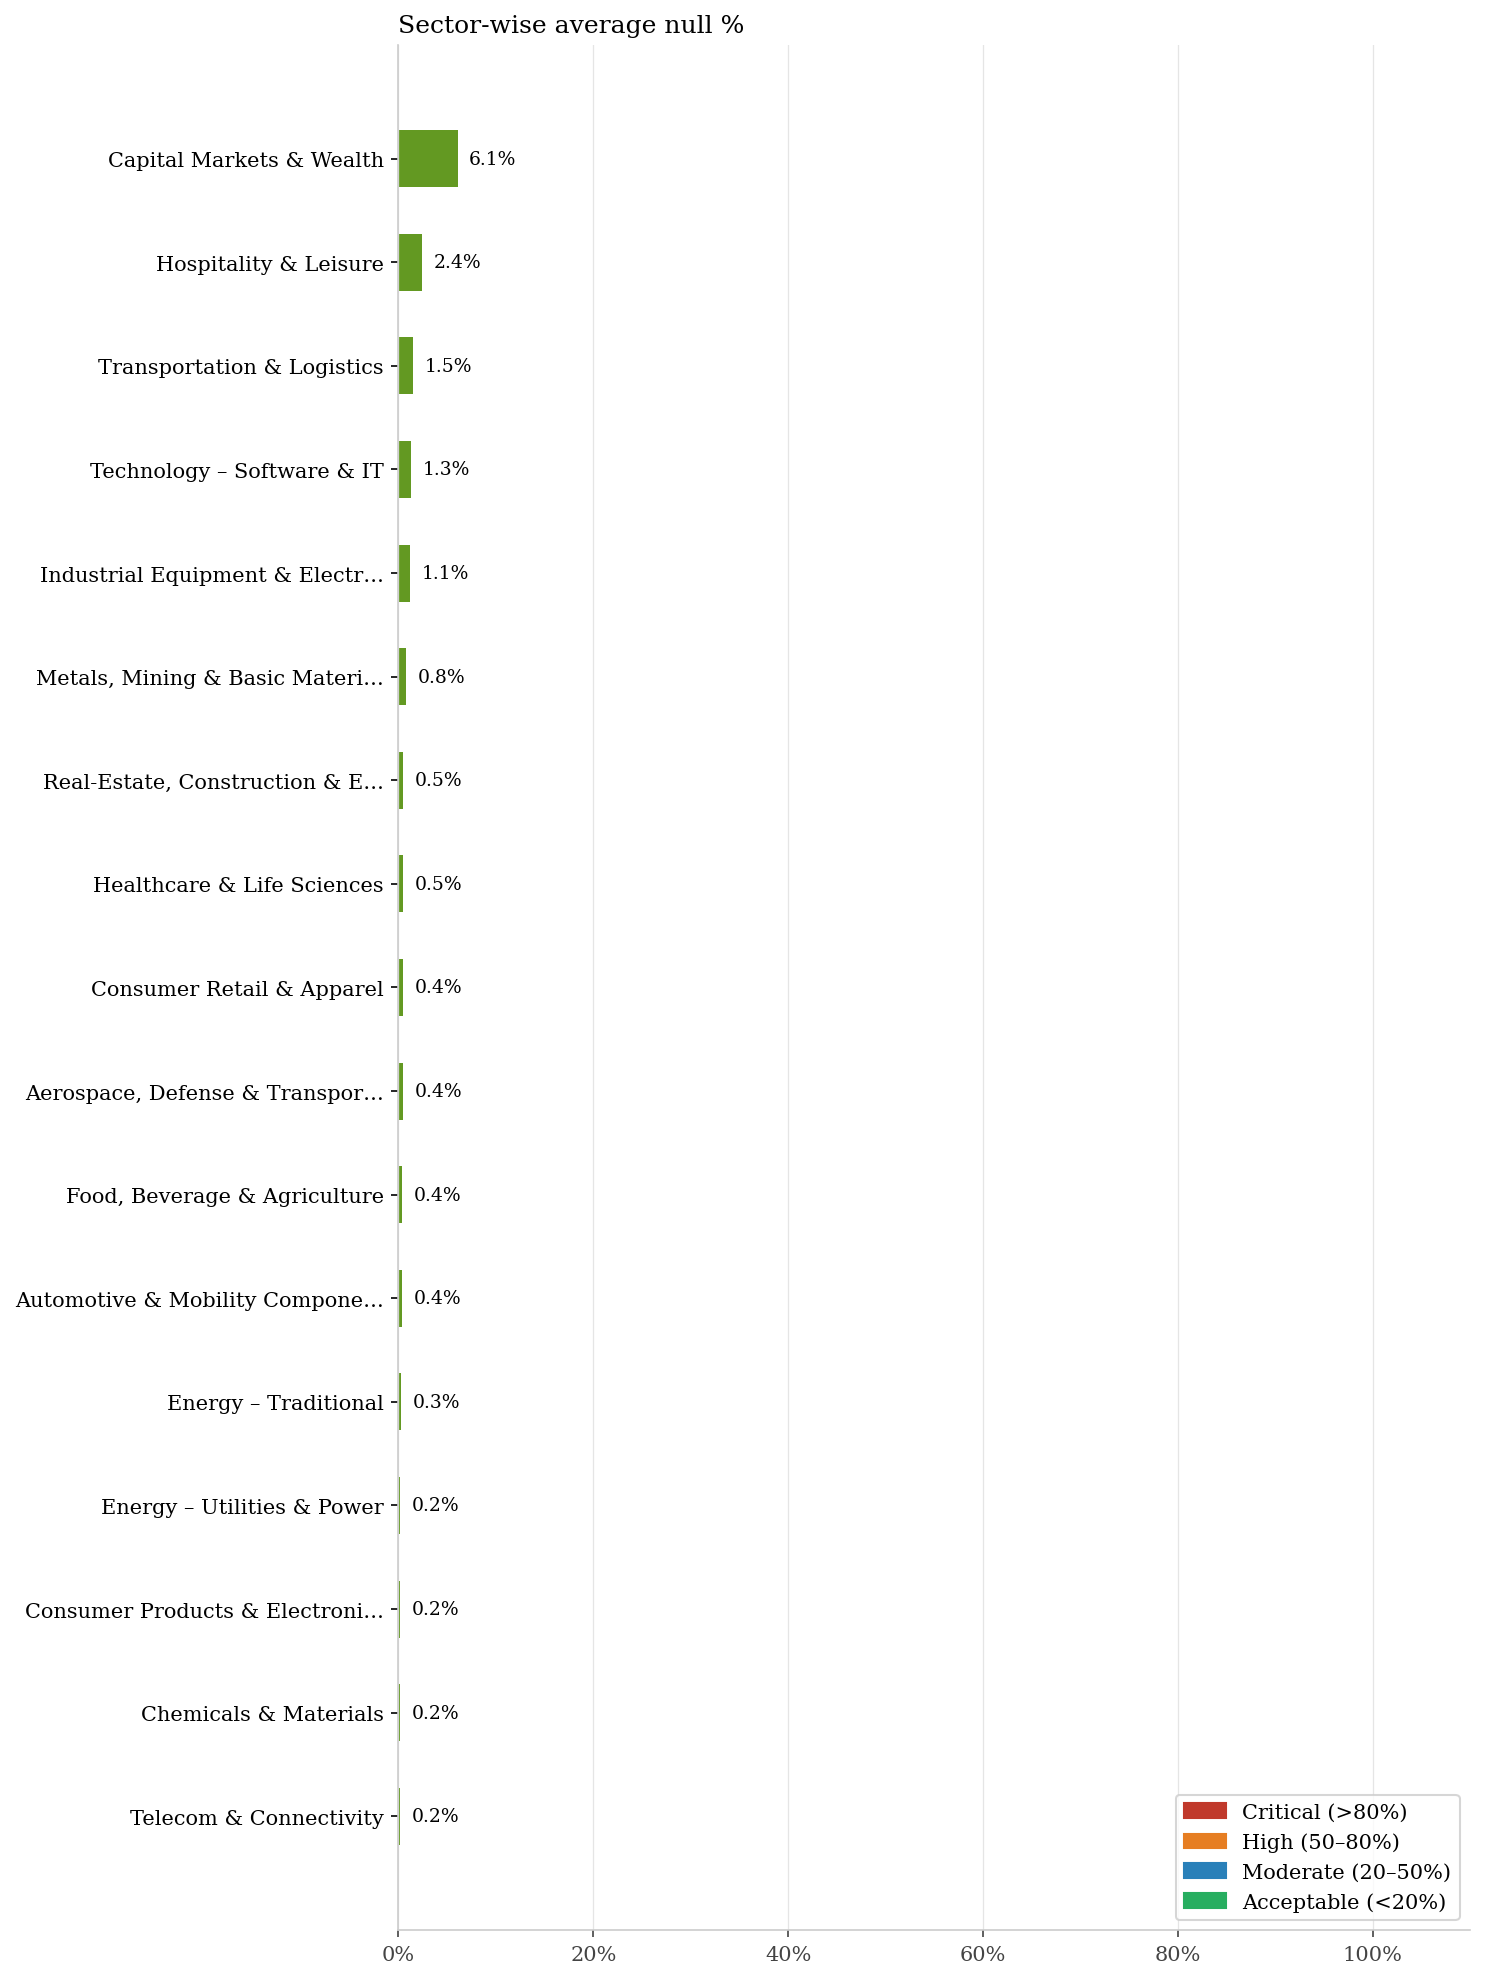

Saved: fig3_heatmap.png
Saved: fig3_heatmap.svg


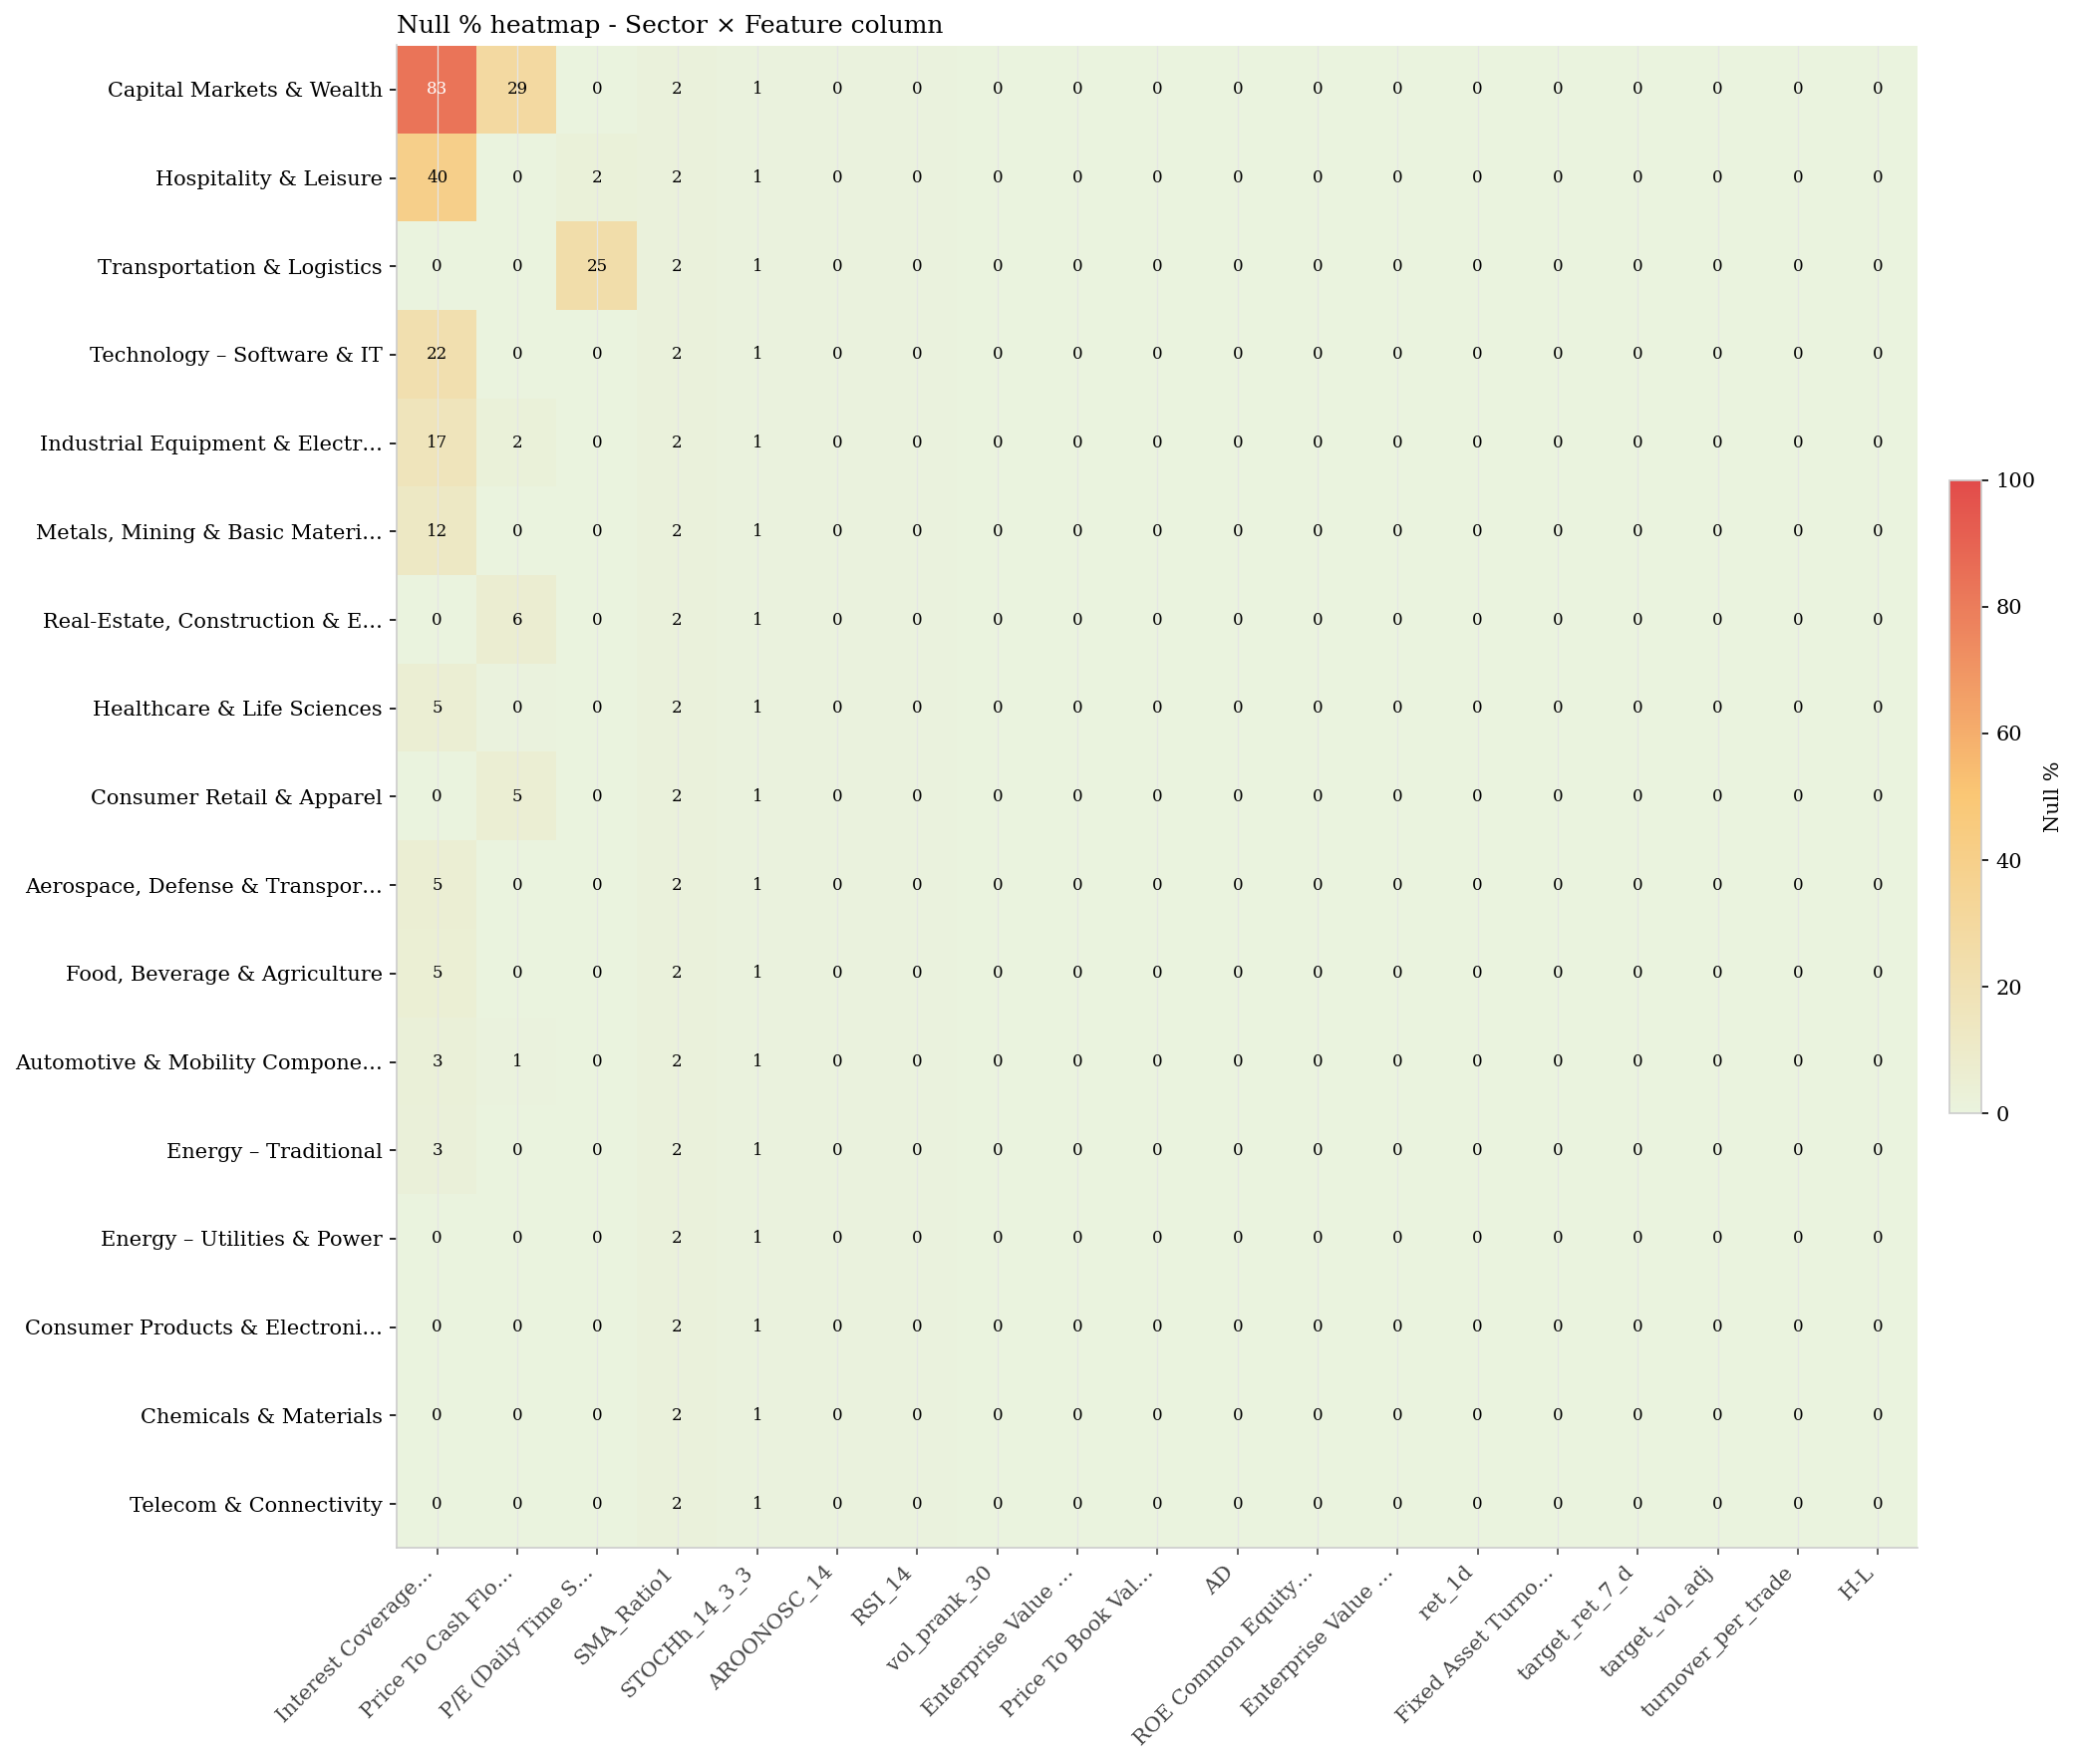

Saved: fig4_sector_drilldown.png
Saved: fig4_sector_drilldown.svg


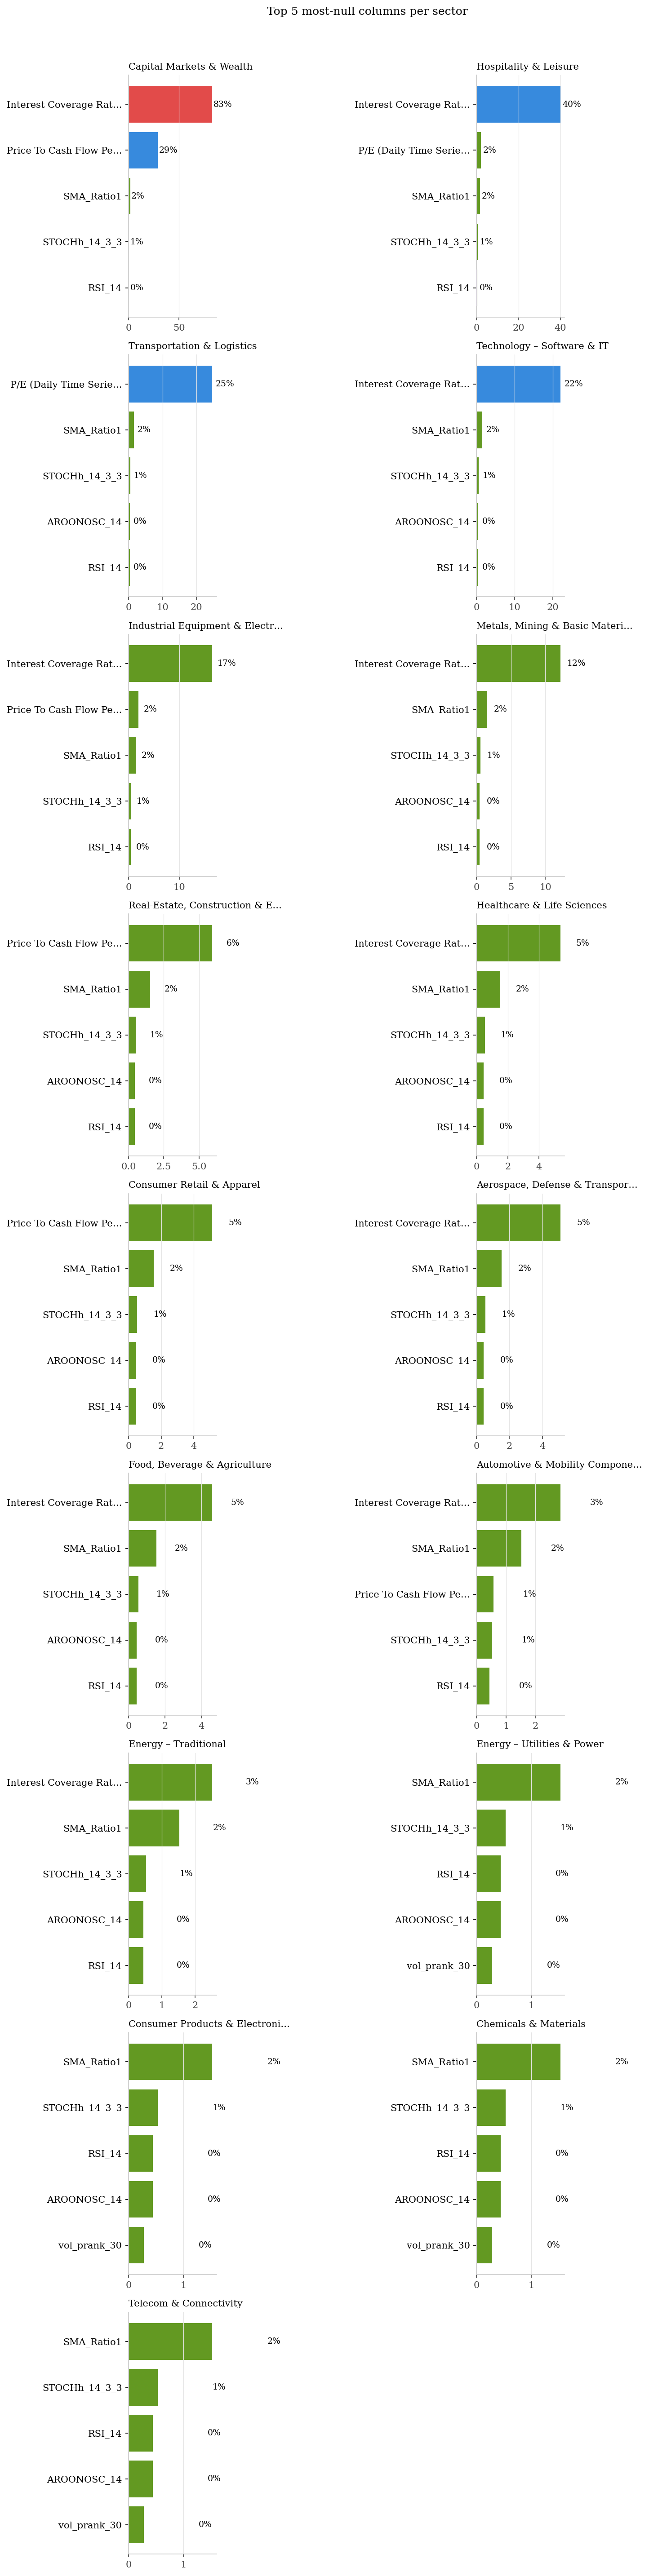

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────
# Helper function for saving plots
# ─────────────────────────────────────────────────────────────────
def save_fig(fig, name):
    """
    Save as:
    - PNG (300 DPI)
    - SVG (vector)
      in working directory (/content)
    """
    fig.savefig(f"{name}.png", dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(f"{name}.svg", bbox_inches="tight", facecolor="white")

    print(f"Saved: {name}.png")
    print(f"Saved: {name}.svg")

# ─────────────────────────────────────────────────────────────────
# DISPLAY STYLE (150 DPI in notebook)
# ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#CCCCCC",
    "axes.grid": True,
    "axes.grid.axis": "x",
    "grid.color": "#E5E5E5",
    "grid.linewidth": 0.6,
    "text.color": "#000000",
    "xtick.color": "#444444",
    "ytick.color": "#000000",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,         # display only
    "savefig.dpi": 300          # saving quality
})


# ─────────────────────────────────────────────────────────────────
# NULL Matrices
# ─────────────────────────────────────────────────────────────────
sector_null = (
    df_main.groupby("Sector")[feature_cols]
    .apply(lambda g: g.isnull().mean() * 100)
    .round(2)
)

sector_summary = (
    sector_null.mean(axis=1)
    .sort_values(ascending=False)
    .reset_index()
)
sector_summary.columns = ["Sector", "Avg_Null_Pct"]

sectors_ordered = sector_summary["Sector"].tolist()

# ─────────────────────────────────────────────────────────────────
# Style Constants
# ─────────────────────────────────────────────────────────────────
def null_color(v):
    if v > 80:  return "#E24B4A"   # red — critical
    if v > 50:  return "#EF9F27"   # amber — high
    if v > 20:  return "#378ADD"   # blue — moderate
    return       "#639922"          # green — ok

def short(s, n=30):
    return s if len(s) <= n else s[:n-1] + "…"                  # name truncation

NULL_CMAP = LinearSegmentedColormap.from_list(
    "null_cmap",
    ["#EAF3DE", "#FAC775", "#E24B4A"],   # green → amber → red
    N=256
)

WHITE     = "#FFFFFF"
# =================================================================
# FIGURE 1 — SECTOR OVERVIEW
# =================================================================
fig1, ax1 = plt.subplots(figsize=(10, max(4, len(sectors_ordered) * 0.7 + 1.4)))
fig1.patch.set_facecolor(WHITE)
ax1.set_facecolor(WHITE)

vals = sector_summary["Avg_Null_Pct"].values
cols = [null_color(v) for v in vals]
ylabs = [short(s) for s in sectors_ordered]

bars = ax1.barh(range(len(vals)), vals, color=cols, height=0.55)

for bar, v in zip(bars, vals):
    ax1.text(min(v + 1.2, 97), bar.get_y() + bar.get_height()/2,
             f"{v:.1f}%", va="center", ha="left", fontsize=9)

ax1.set_yticks(range(len(vals)))
ax1.set_yticklabels(ylabs)
ax1.set_xlim(0, 110)
ax1.xaxis.set_major_formatter(mticker.PercentFormatter())
ax1.invert_yaxis()
ax1.set_title("Sector-wise average null %", loc="left")

legend_items = [
    mpatches.Patch(color="#C0392B", label="Critical (>80%)"),
    mpatches.Patch(color="#E67E22", label="High (50–80%)"),
    mpatches.Patch(color="#2980B9", label="Moderate (20–50%)"),
    mpatches.Patch(color="#27AE60", label="Acceptable (<20%)"),
]

ax1.legend(handles=legend_items, loc="lower right")

fig1.tight_layout()
save_fig(fig1, "fig2_sector_overview")
plt.show()


# =================================================================
# FIGURE 2 — HEATMAP
# =================================================================
col_order = sector_null.mean(axis=0).sort_values(ascending=False).index
heat_data = sector_null.loc[sectors_ordered, col_order]

fig2, ax2 = plt.subplots(
    figsize=(max(14, len(col_order)*0.55), max(5, len(sectors_ordered)*0.7))
)

im = ax2.imshow(heat_data.values, cmap=NULL_CMAP, aspect="auto", vmin=0, vmax=100)

ax2.set_xticks(range(len(col_order)))
ax2.set_xticklabels([short(c, 18) for c in col_order], rotation=45, ha="right")
ax2.set_yticks(range(len(sectors_ordered)))
ax2.set_yticklabels([short(s) for s in sectors_ordered])

for r in range(len(sectors_ordered)):
    for c in range(len(col_order)):
        v = heat_data.iloc[r, c]
        ax2.text(c, r, f"{v:.0f}",
                 ha="center", va="center",
                 color="white" if v > 55 else "black",
                 fontsize=8)

fig2.colorbar(im, ax=ax2, fraction=0.02, pad=0.02, label="Null %")
ax2.set_title("Null % heatmap - Sector × Feature column", loc="left")

fig2.tight_layout()
save_fig(fig2, "fig3_heatmap")
plt.show()


# =================================================================
# FIGURE 3 — DRILLDOWN
# =================================================================
TOP_N = 5
n_secs = len(sectors_ordered)
ncols_g = min(2, n_secs)
nrows_g = (n_secs + ncols_g - 1) // ncols_g

fig3, axes = plt.subplots(nrows_g, ncols_g, figsize=(ncols_g*5.5, nrows_g*4.2))
axes_flat = axes.flatten() if n_secs > 1 else [axes]

for i, sec in enumerate(sectors_ordered):
    ax = axes_flat[i]

    top = sector_null.loc[sec].sort_values(ascending=False).head(TOP_N)

    bars = ax.barh(range(len(top)), top.values,
                   color=[null_color(v) for v in top.values])

    for bar, v in zip(bars, top.values):
        ax.text(min(v + 1, 97), bar.get_y() + bar.get_height()/2,
                f"{v:.0f}%", va="center", fontsize=9)

    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([short(c, 22) for c in top.index])
    ax.invert_yaxis()
    ax.set_title(short(sec), loc="left", fontsize=10)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig3.suptitle(f"Top {TOP_N} most-null columns per sector", y=1.01)

fig3.tight_layout()
save_fig(fig3, "fig4_sector_drilldown")
plt.show()

In [ ]:
# saving df without NaNs
nan_before = master_df_full[feature_cols_new].isnull().sum().sum()
master_df_full[feature_cols_new] = master_df_full[feature_cols_new].fillna(0)
nan_after = master_df_full[feature_cols_new].isnull().sum().sum()

print(f"  NaN before : {nan_before:,}")
print(f"  NaN after  : {nan_after:,}  {'✓' if nan_after == 0 else 'still NaN, investigate'}")
master_df_full.to_parquet(f"master_df_full_pruned_without_na_d{master_df_full.shape[1]}.parquet", index=False)

  NaN before : 50,592
  NaN after  : 0  ✓


#### Final Sanity Check

In [ ]:
# ──Final Sanity Check — 5 checks, all must pass ──

print("\n" + "=" * 55)
print("  MASTER DATAFRAME — FINAL STATE")
print("=" * 55)
print(f"  Shape                : {master_df_full.shape}")
print(f"  Stocks               : {master_df_full['Symbol'].nunique()}")
print(f"  Date range           : {master_df_full['Date'].min().date()} "
      f"→ {master_df_full['Date'].max().date()}")
print(f"  Trading days         : {master_df_full['Date'].nunique()}")
print(f"  Features for model   : {len(feature_cols_new)}")
print(f"  Target column        : {TARGET_COL}  (HORIZON={HORIZON}d)")
print()

# Check 1: zero NaN in features
nan_final = master_df_full[feature_cols_new].isnull().sum().sum()
check1    = nan_final == 0
print(f"  Check 1 — NaN in features      : {nan_final}  "
      f"{'✓' if check1 else '✗  must be 0 before graph building'}")

# Check 2: target column present
check2 = TARGET_COL in master_df_full.columns
print(f"  Check 2 — Target col exists    : "
      f"{'✓' if check2 else f'✗  {TARGET_COL} missing'}")

# Check 3: target NaN within acceptable range
target_nan   = master_df_full[TARGET_COL].isnull().sum()
target_total = len(master_df_full)
check3       = (target_nan / target_total * 100) <= 5.0
print(f"  Check 3 — Target NaN           : {target_nan:,} / {target_total:,} "
      f"({target_nan/target_total:.2%})  "
      f"{'✓' if check3 else '✗  unusually high'}")

# Check 4: equal rows per stock (reindex worked)
rows_check = master_df_full.groupby("Symbol").size()
check4     = rows_check.nunique() == 1
print(f"  Check 4 — Rows per stock       : min={rows_check.min()}  max={rows_check.max()}  "
      f"{'✓' if check4 else '✗  unequal — GraphBuilder will crash'}")

# Check 5: ret_1d NaN-free
if 'ret_1d' in master_df_full.columns:
    ret1d_final = master_df_full['ret_1d'].isnull().sum()
    check5      = ret1d_final == 0
    print(f"  Check 5 — ret_1d NaN-free      : {ret1d_final}  "
          f"{'✓  GraphBuilder edge computation safe' if check5 else '✗  will skip date windows'}")
else:
    check5 = False
    print(f"  Check 5 — ret_1d NaN-free      : ✗  column missing")

# Check 6: target_ret_7d exists in master_df
check6 = 'target_ret_7_d' in master_df_full.columns
print(f"  Check 6 — target_ret_7_d       : "
      f"{'✓  available in data' if check6 else '✗  column missing'}")

all_ok = check1 and check2 and check3 and check4 and check5 and check6
print(f"\n  {'─'*51}")
print(f"  {'✓  All checks passed — ready for (Graph Building)' if all_ok else '✗  Fix issues above before continuing'}")
print("=" * 55)

# ── Save master_df_full Checkpoint ────────────────
# Saves the fully processed master_df_full to disk.
# Useful for:
#   - Inspecting features without rerunning Chunks 1-4
#   - Debugging target construction
#   - Verifying feature values against raw data
#
# NOTE: this is a large file (~500MB–1GB depending on stock count)
# Load with: master_df_full = pd.read_parquet(MASTER_DF_PATH)

# import os
MASTER_DF_PATH = f"/content/master_df_full_{HORIZON}d.parquet"            # finalized
# create directory if it doesn't exist
os.makedirs(os.path.dirname(MASTER_DF_PATH), exist_ok=True)

print("Saving master_df_full...")
master_df_full.to_parquet(MASTER_DF_PATH, index=False)
size_mb = os.path.getsize(MASTER_DF_PATH) / 1e6
print(f"  ✓  Saved → {MASTER_DF_PATH}  ({size_mb:.1f} MB)")

# quick verification
df_check = pd.read_parquet(MASTER_DF_PATH)
print(f"  ✓  Reloaded shape   : {df_check.shape}")
print(f"  ✓  Stocks           : {df_check['Symbol'].nunique()}")
print(f"  ✓  Date range       : {df_check['Date'].min().date()} → {df_check['Date'].max().date()}")
print(f"  ✓  Features         : {len(feature_cols_new)}")
del df_check



  MASTER DATAFRAME — FINAL STATE
  Shape                : (329806, 25)
  Stocks               : 103
  Date range           : 2012-01-02 → 2024-12-31
  Trading days         : 3202
  Features for model   : 17
  Target column        : target_vol_adj  (HORIZON=7d)

  Check 1 — NaN in features      : 0  ✓
  Check 2 — Target col exists    : ✓
  Check 3 — Target NaN           : 0 / 329,806 (0.00%)  ✓
  Check 4 — Rows per stock       : min=3202  max=3202  ✓
  Check 5 — ret_1d NaN-free      : 0  ✓  GraphBuilder edge computation safe
  Check 6 — target_ret_7_d       : ✓  available in data

  ───────────────────────────────────────────────────
  ✓  All checks passed — ready for (Graph Building)
Saving master_df_full...
  ✓  Saved → /content/master_df_full_7d.parquet  (41.3 MB)
  ✓  Reloaded shape   : (329806, 25)
  ✓  Stocks           : 103
  ✓  Date range       : 2012-01-02 → 2024-12-31
  ✓  Features         : 17


In [ ]:
print("Saving Feature cols...")
print(feature_cols_new)
import pickle
with open(f"feature_cols_new.pkl", "wb") as f:
  pickle.dump(feature_cols_new, f)
print("Feature Columns Saved!")

Saving Feature cols...
['RSI_14', 'STOCHh_14_3_3', 'AROONOSC_14', 'AD', 'P/E (Daily Time Series Ratio)', 'Enterprise Value To EBITDA (Daily Time Series Ratio)', 'Price To Book Value Per Share (Daily Time Series Ratio)', 'Price To Cash Flow Per Share (Daily Time Series Ratio)', 'Enterprise Value To Sales (Daily Time Series Ratio)', 'ROE Common Equity %', 'Interest Coverage Ratio', 'Fixed Asset Turnover, Period-Period Diff', 'Interest Coverage Ratio_flag', 'vol_prank_30', 'turnover_per_trade', 'SMA_Ratio1', 'H-L']
Feature Columns Saved!


In [ ]:
# Uploading Data outputs to GCS
# Step 1 Directory for H1

# DIR = f"centralefs/modelfiles/h{HORIZON}"
DIR = f"centralefs/modelfiles/pfeats7u"
# centralefs/modelfiles/pfeats7u

print("\n Uploading Data to GCS...")
!gsutil -m cp fig1_eda_1_feature_corr.svg  gs://{DIR}/step1/
!gsutil -m cp fig2_sector_overview.png     gs://{DIR}/step1/
!gsutil -m cp fig2_sector_overview.svg   gs://{DIR}/step1/
!gsutil -m cp fig3_heatmap.png   gs://{DIR}/step1/
!gsutil -m cp fig3_heatmap.svg   gs://{DIR}/step1/
!gsutil -m cp fig4_sector_drilldown.png   gs://{DIR}/step1/
!gsutil -m cp fig4_sector_drilldown.svg   gs://{DIR}/step1/

# !gsutil -m cp master_df_full_1D.parquet gs://{DIR}/step1/
# !gsutil cp    master_df_full_pruned_without_na_d61.parquet gs://{DIR}/step1/ 2>/dev/null || true

# !gsutil -m cp feature_cols_new.pkl gs://final_eda1/daily/ # MAD A MESS
!gsutil -m cp feature_cols_new.pkl gs://{DIR}/step1/

!gsutil -m cp master_df_full_7d.parquet gs://{DIR}/step1/
!gsutil cp    master_df_full_pruned_without_na_d25.parquet gs://{DIR}/step1/ 2>/dev/null || true

print("Data uploaded")


 Uploading Data to GCS...
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://fig1_eda_1_feature_corr.svg [Content-Type=image/svg+xml]...
/ [1/1 files][  1.0 KiB/  1.0 KiB] 100% Done                                    
Operation completed over 1 objects/1.0 KiB.                                      
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://fig2_sector_overview.png [Content-Type=image/png]...
/ [1/1 files][395.5 KiB/395.5 KiB] 100% Done                                    
Operation completed over 1 objects/395.5 KiB.                       

#### Returns Plot on Train Data (Target being vol adjusted returns)

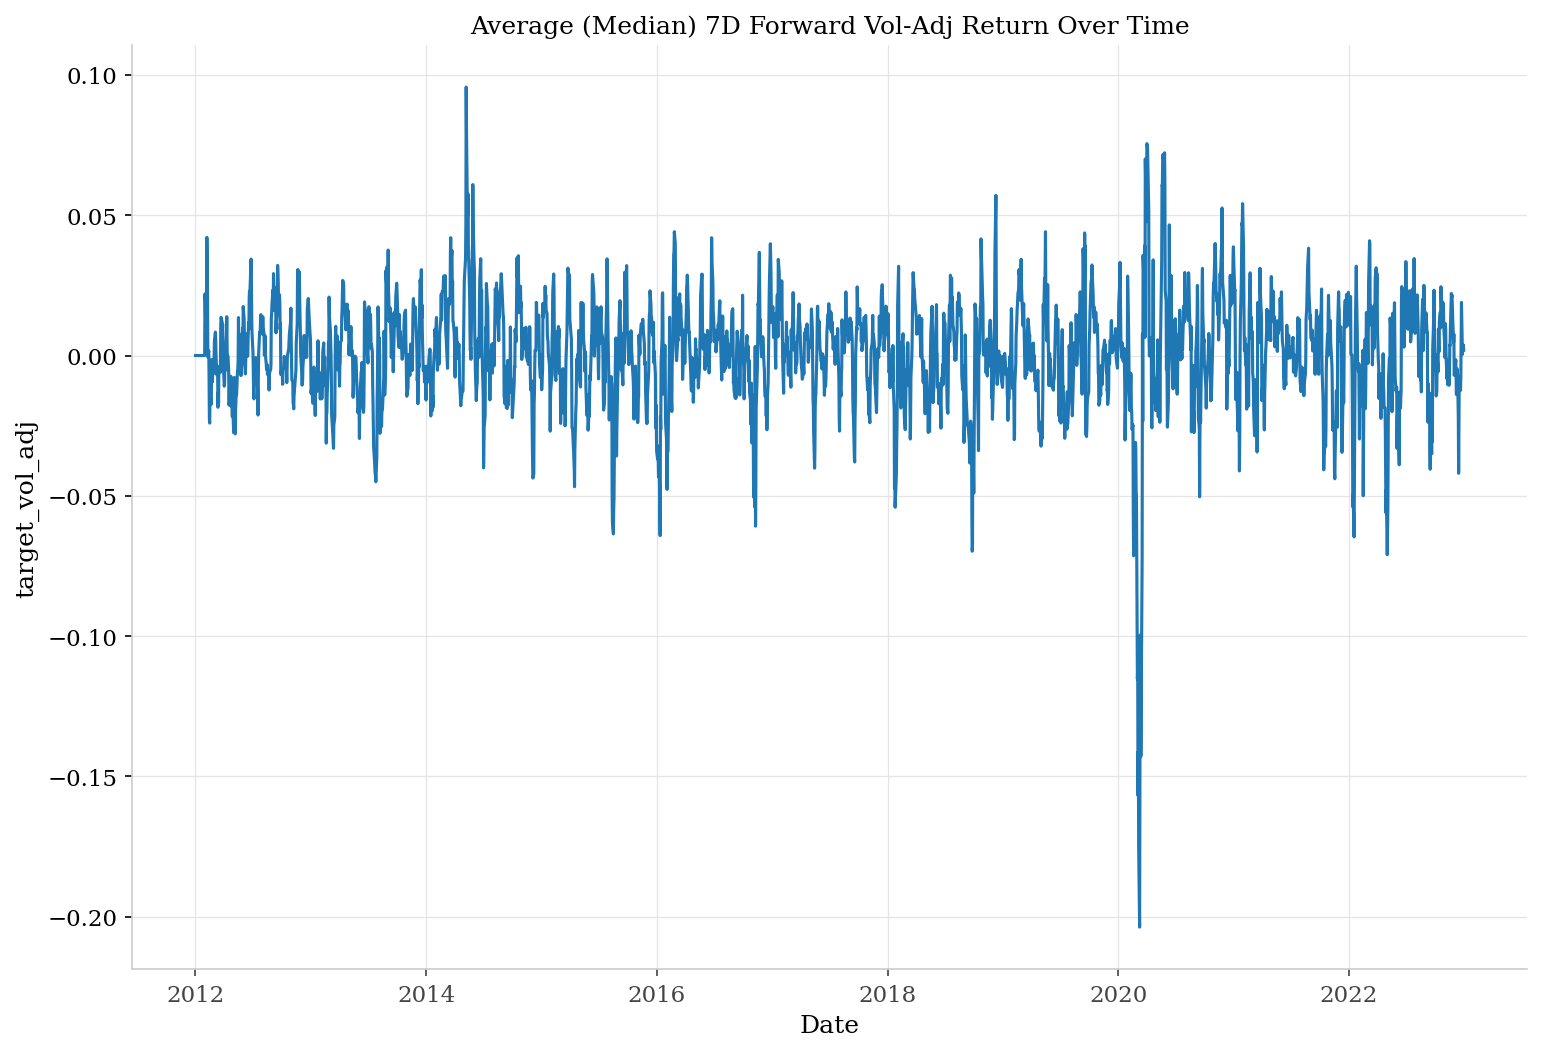

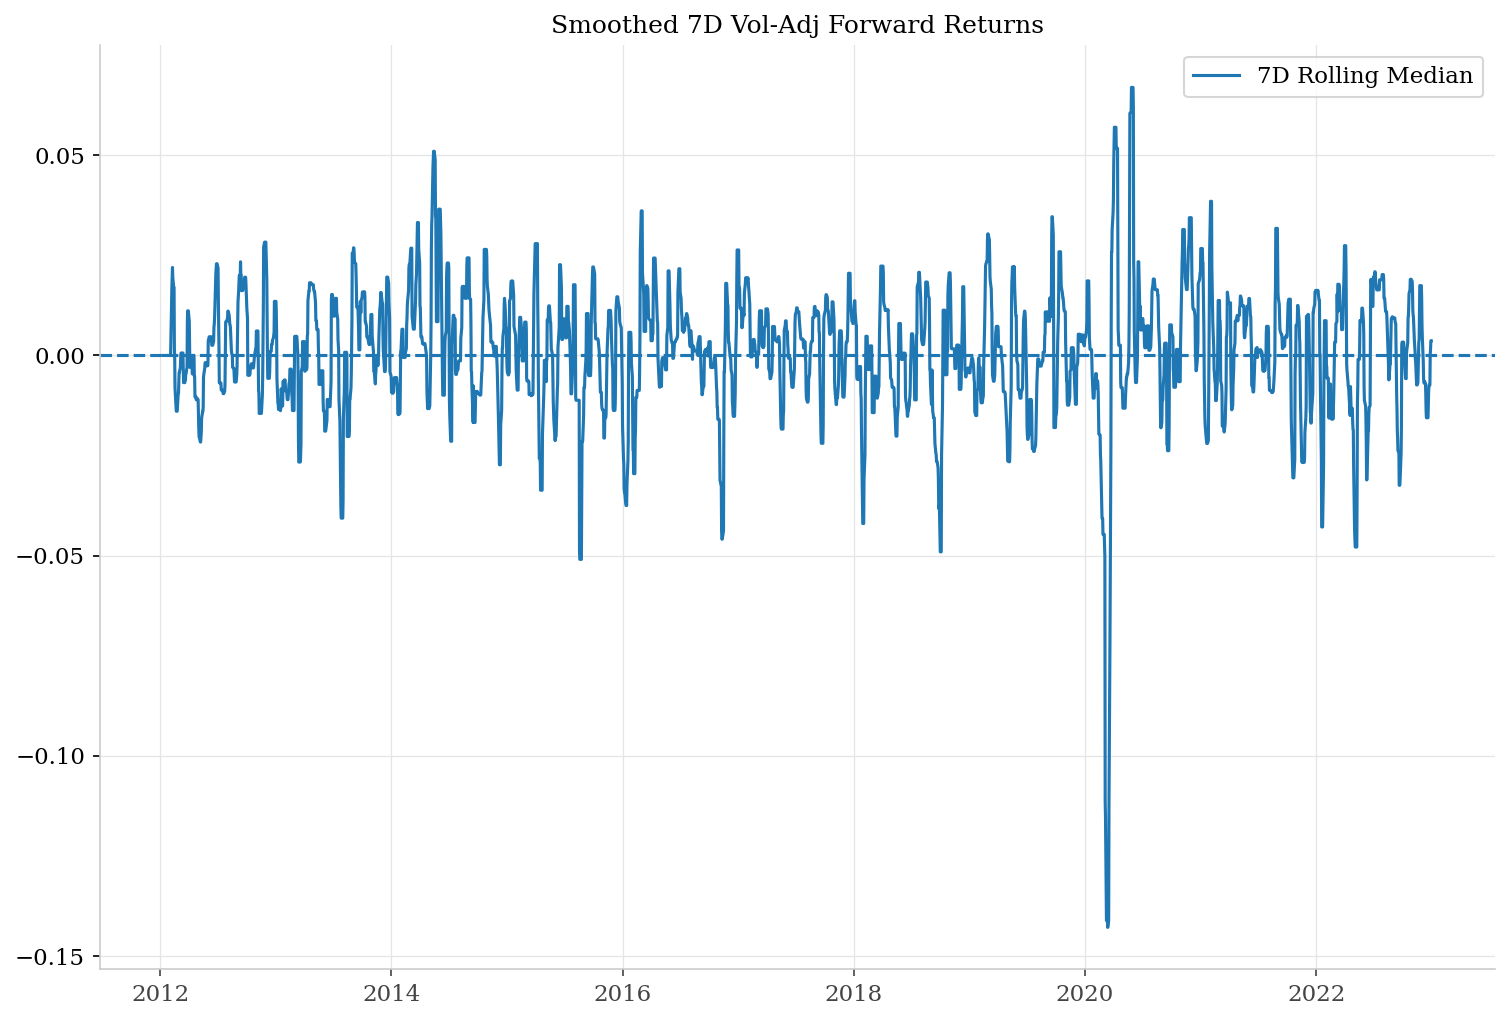

In [ ]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

df = master_df_full[master_df_full['split']=='train'].copy()

# ensure datetime
df["Date"] = pd.to_datetime(df["Date"])

# average across symbols per day
daily_7d_ret = (
    df.groupby("Date")[TARGET_COL]
    .median()                             # median to exclude outlier returns
    .sort_index()
)
plt.figure(figsize=(12, 8))
plt.plot(daily_7d_ret.index, daily_7d_ret.values)
plt.title(f"Average (Median) {HORIZON}D Forward Vol-Adj Return Over Time")
plt.xlabel("Date")
plt.ylabel(TARGET_COL)
plt.grid(True)
plt.show()

# 7 day rolling returns
rolling_ret = daily_7d_ret.rolling(7).median()  # 7-day smoothing
plt.figure(figsize=(12, 8))
plt.plot(rolling_ret.index, rolling_ret.values, label="7D Rolling Median")
plt.axhline(0, linestyle="--")
plt.title(f"Smoothed {HORIZON}D Vol-Adj Forward Returns")
plt.legend()
plt.grid(True)
plt.show()


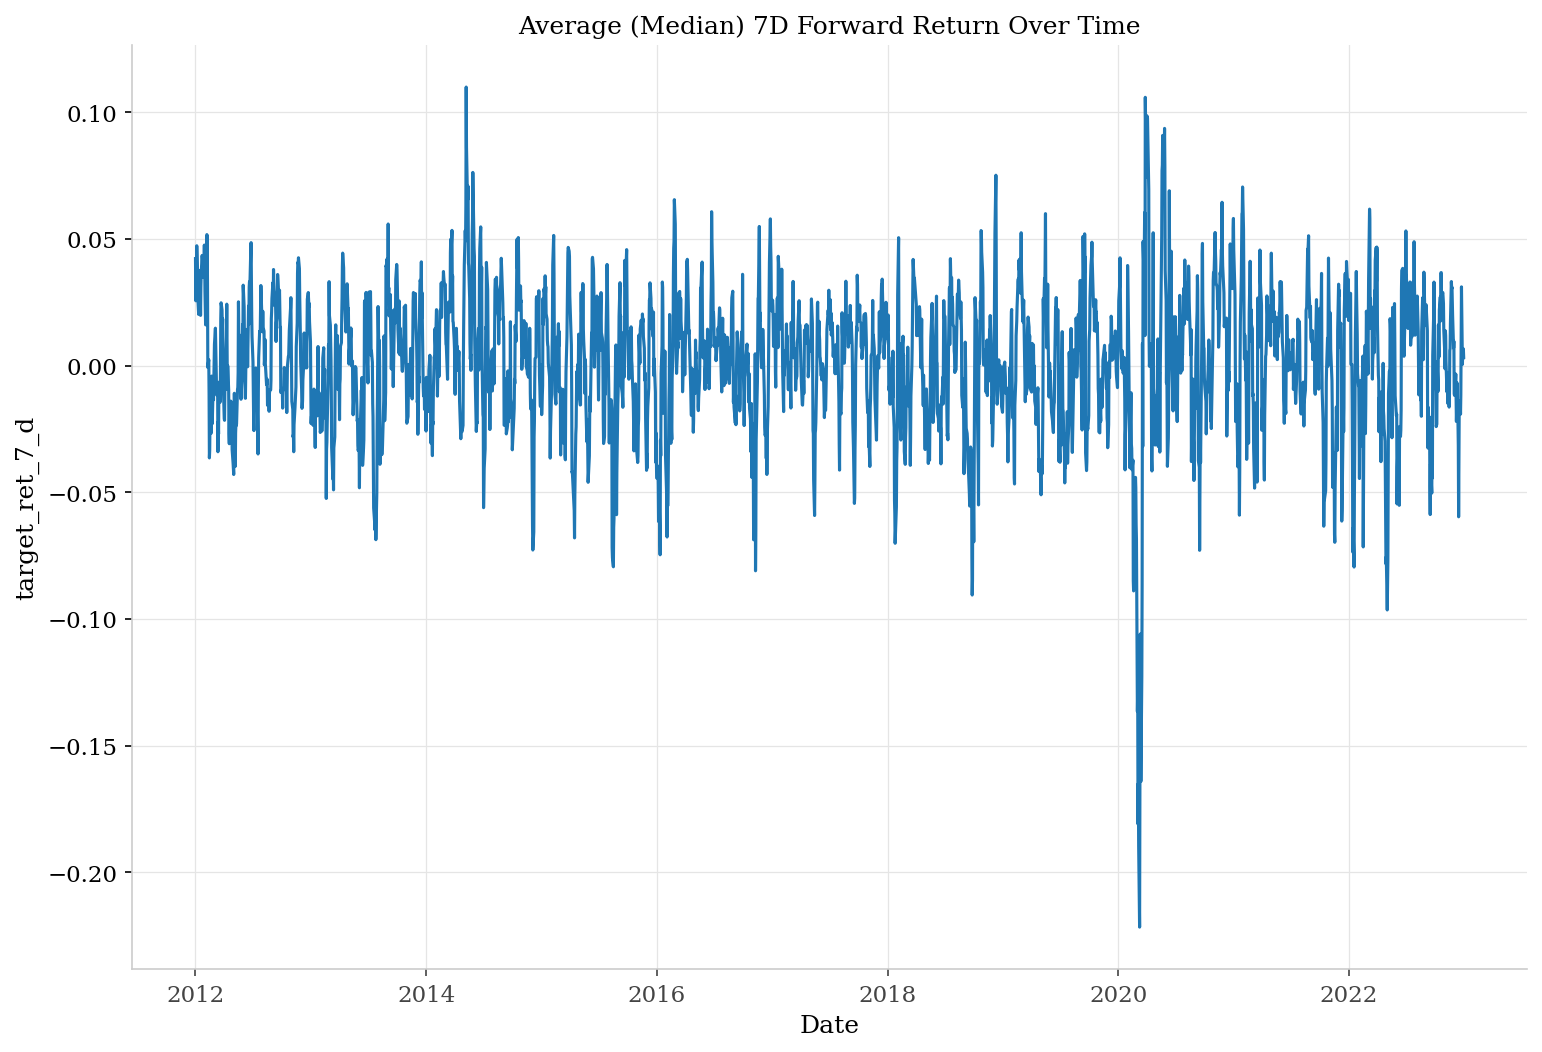

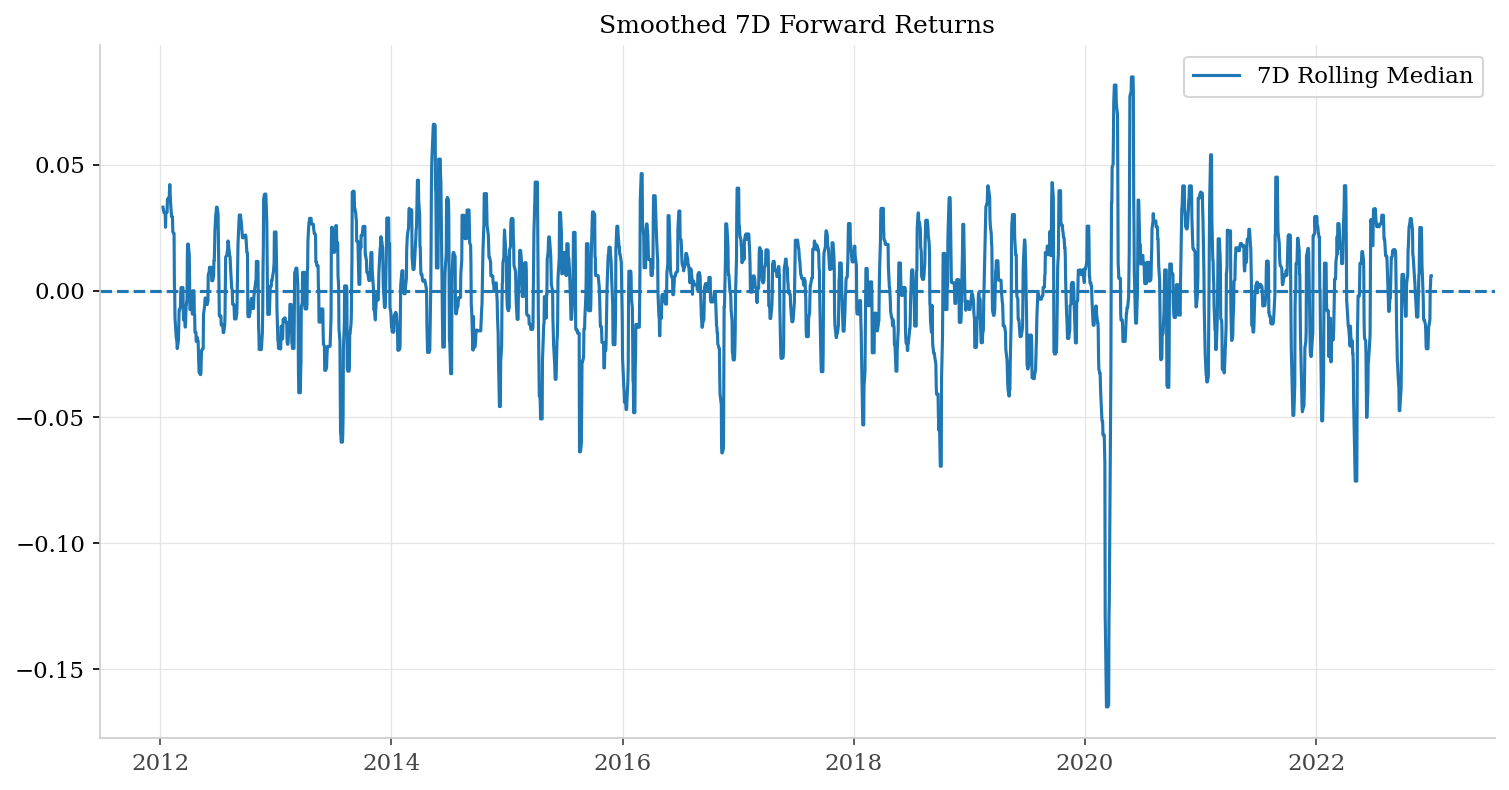

In [ ]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

df = master_df_full[master_df_full['split']=='train'].copy()

# ensure datetime
df["Date"] = pd.to_datetime(df["Date"])

# average across symbols per day
daily_7d_ret = (
    df.groupby("Date")['target_ret_7_d']
    .median()                             # median to exclude outlier returns
    .sort_index()
)
plt.figure(figsize=(12, 8))
plt.plot(daily_7d_ret.index, daily_7d_ret.values)
plt.title(f"Average (Median) {HORIZON}D Forward Return Over Time")
plt.xlabel("Date")
plt.ylabel('target_ret_7_d')
plt.grid(True)
plt.show()

# 7 day rolling returns
rolling_ret = daily_7d_ret.rolling(7).median()  # 7-day smoothing
plt.figure(figsize=(12, 6))
plt.plot(rolling_ret.index, rolling_ret.values, label="7D Rolling Median")
plt.axhline(0, linestyle="--")
plt.title(f"Smoothed {HORIZON}D Forward Returns")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
############################################################################################################
# Test for stationarity for returns
# ADF Test
# ADF (Augmented Dickey-Fuller) Test
# Null hypothesis (H0): The series is non-stationary (has a unit root).
# Alternative (H1): The series is stationary.
############################################################################################################
from statsmodels.tsa.stattools import adfuller, kpss

result = adfuller(daily_7d_ret.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

# ADF - H0 -> Non-Stationary | H1 -> Stationary

############################################################################################################
# KPSS Test

kpss_stat, p_value, lags, crit_vals = kpss(daily_7d_ret.dropna(), regression='c')

print("KPSS Statistic:", kpss_stat)
print("p-value:", p_value)
print("Critical Values:")
for key, value in crit_vals.items():
    print(f"   {key}: {value}")
# KPSS - H0 -> Stationary | H1 -> Non-Stationary
############################################################################################################

ADF Statistic: -10.16246646683027
p-value: 7.445751537284824e-18
Critical Values:
   1%: -3.4327869175173453
   5%: -2.8626166499894
   10%: -2.5673431369296353
KPSS Statistic: 0.07764743801591094
p-value: 0.1
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739


/tmp/ipykernel_5952/43579237.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, p_value, lags, crit_vals = kpss(daily_7d_ret.dropna(), regression='c')


Avg (Mean) positive regime length of regime 1 runs: 38.475
Avg (Mean) duration of regime 0 runs: 28.585365853658537
Avg (Median) positive regime length of regime 1 (+ve) runs: 31.5
Avg (Median) duration of regime 0 (-ve) runs: 29.0


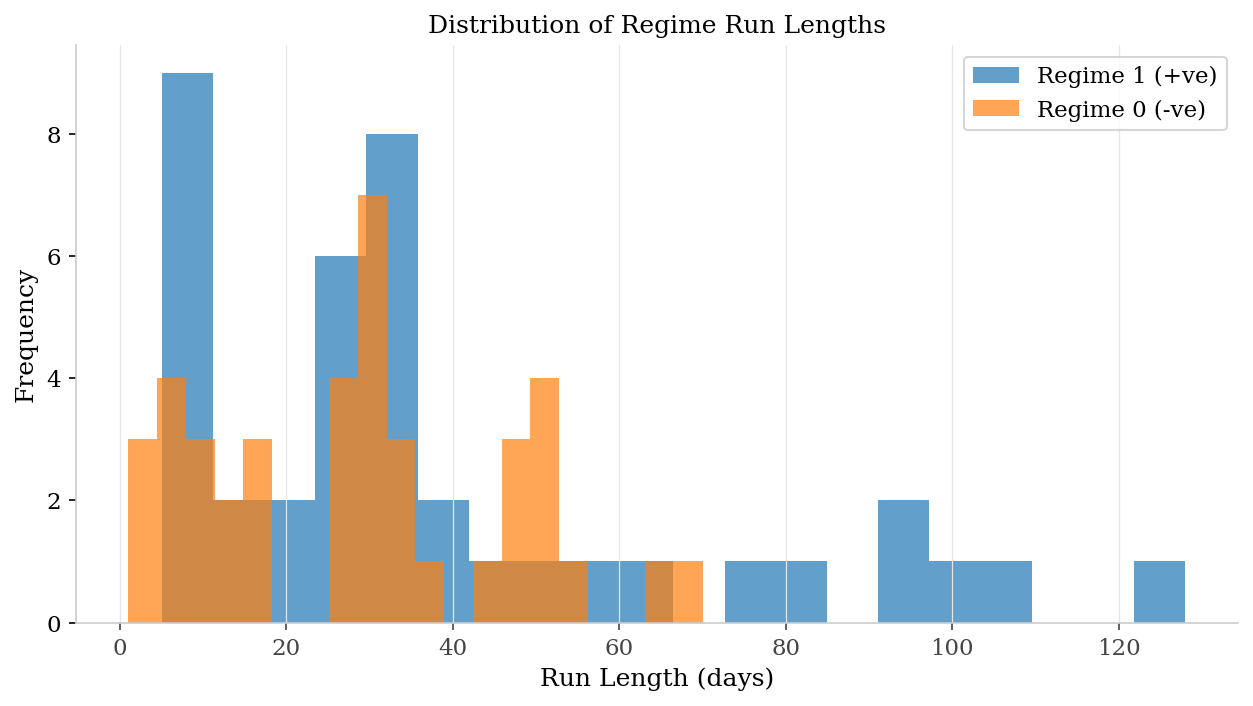

In [ ]:
#### Regime analysis

rolling_mean = daily_7d_ret.rolling(30).mean()
rolling_mean.iloc[30:60]
regime = (rolling_mean > 0).astype(int)
regime.head(60)
regime_shift = regime.diff()

group_ids = (regime != regime.shift()).cumsum()

# lengths of each run
run_lengths = regime.groupby(group_ids).size()

# avg length of regime 1 runs
avg_regime1 = run_lengths[regime.groupby(group_ids).first() == 1].mean()

# avg length of regime 0 runs
avg_regime0 = run_lengths[regime.groupby(group_ids).first() == 0].mean()

print("Avg (Mean) positive regime length of regime 1 runs:", avg_regime1)
print("Avg (Mean) duration of regime 0 runs:", avg_regime0)

# avg length of regime 1 runs
avg_regime1 = run_lengths[regime.groupby(group_ids).first() == 1].median()

# avg length of regime 0 runs
avg_regime0 = run_lengths[regime.groupby(group_ids).first() == 0].median()

print("Avg (Median) positive regime length of regime 1 (+ve) runs:", avg_regime1)
print("Avg (Median) duration of regime 0 (-ve) runs:", avg_regime0)

################################################################################

# Identify groups (consecutive runs)
group_ids = (regime != regime.shift()).cumsum()

# Get run lengths
run_lengths = regime.groupby(group_ids).size()

# Identify which runs are regime 1 vs regime 0
run_type = regime.groupby(group_ids).first()

regime1_lengths = run_lengths[run_type == 1]
regime0_lengths = run_lengths[run_type == 0]

# Plot
plt.figure(figsize=(10,5))
plt.hist(regime1_lengths, bins=20, alpha=0.7, label='Regime 1 (+ve)')
plt.hist(regime0_lengths, bins=20, alpha=0.7, label='Regime 0 (-ve) ')
plt.xlabel('Run Length (days)')
plt.ylabel('Frequency')
plt.title('Distribution of Regime Run Lengths')
plt.legend()
plt.show()

################################################################################

In [ ]:
#### the 30-day moving average (of 7day returns) stayed positive for n days

#### Plots

In [ ]:
# ─────────────────────────────────────────────────────────────
# GLOBAL STYLE ................................................
# ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":         "serif",
    "font.serif":          ["Times New Roman", "Times", "DejaVu Serif"],
    "figure.facecolor":    "white",
    "axes.facecolor":      "white",
    "savefig.facecolor":   "white",
    "savefig.dpi":         300,
    "figure.dpi":          300,          # screen preview
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.spines.left":    True,
    "axes.spines.bottom":  True,
    "axes.linewidth":      0.8,
    "axes.edgecolor":      "#CCCCCC",
    "axes.grid":           True,
    "grid.color":          "#E5E5E5",
    "grid.linewidth":      0.6,
    "text.color":          "#000000",
    "xtick.color":         "#444444",
    "ytick.color":         "#000000",
    "xtick.labelsize":     9,
    "ytick.labelsize":     9,
    "axes.titlesize":      11,
    "axes.titleweight":    "bold",
    "axes.labelsize":      10,
    "legend.fontsize":     9,
    "legend.framealpha":   1.0,
    "legend.edgecolor":    "#CCCCCC",
})

# Palette — readable in greyscale print too
C_BLUE   = "#2471A3"
C_ORANGE = "#CA6F1E"
C_GREEN  = "#1E8449"
C_RED    = "#C0392B"
C_PURPLE = "#6C3483"

SAVE_KW  = dict(dpi=300, bbox_inches="tight", facecolor="white")

  DATASET OVERVIEW
  Shape              : (279233, 25)
  Date range         : 2012-01-02 -> 2022-12-30
  Trading days       : 2711
  Stocks             : 103
  Feature cols total : 17
    Continuous       : 17
    Flag features    : 1
  Rows per stock avg : 2711

  Missing values in features:
    Features with any NaN : 0  ok - none

  Stocks per trading day:
    Min / Mean / Max : 103 / 103.0 / 103


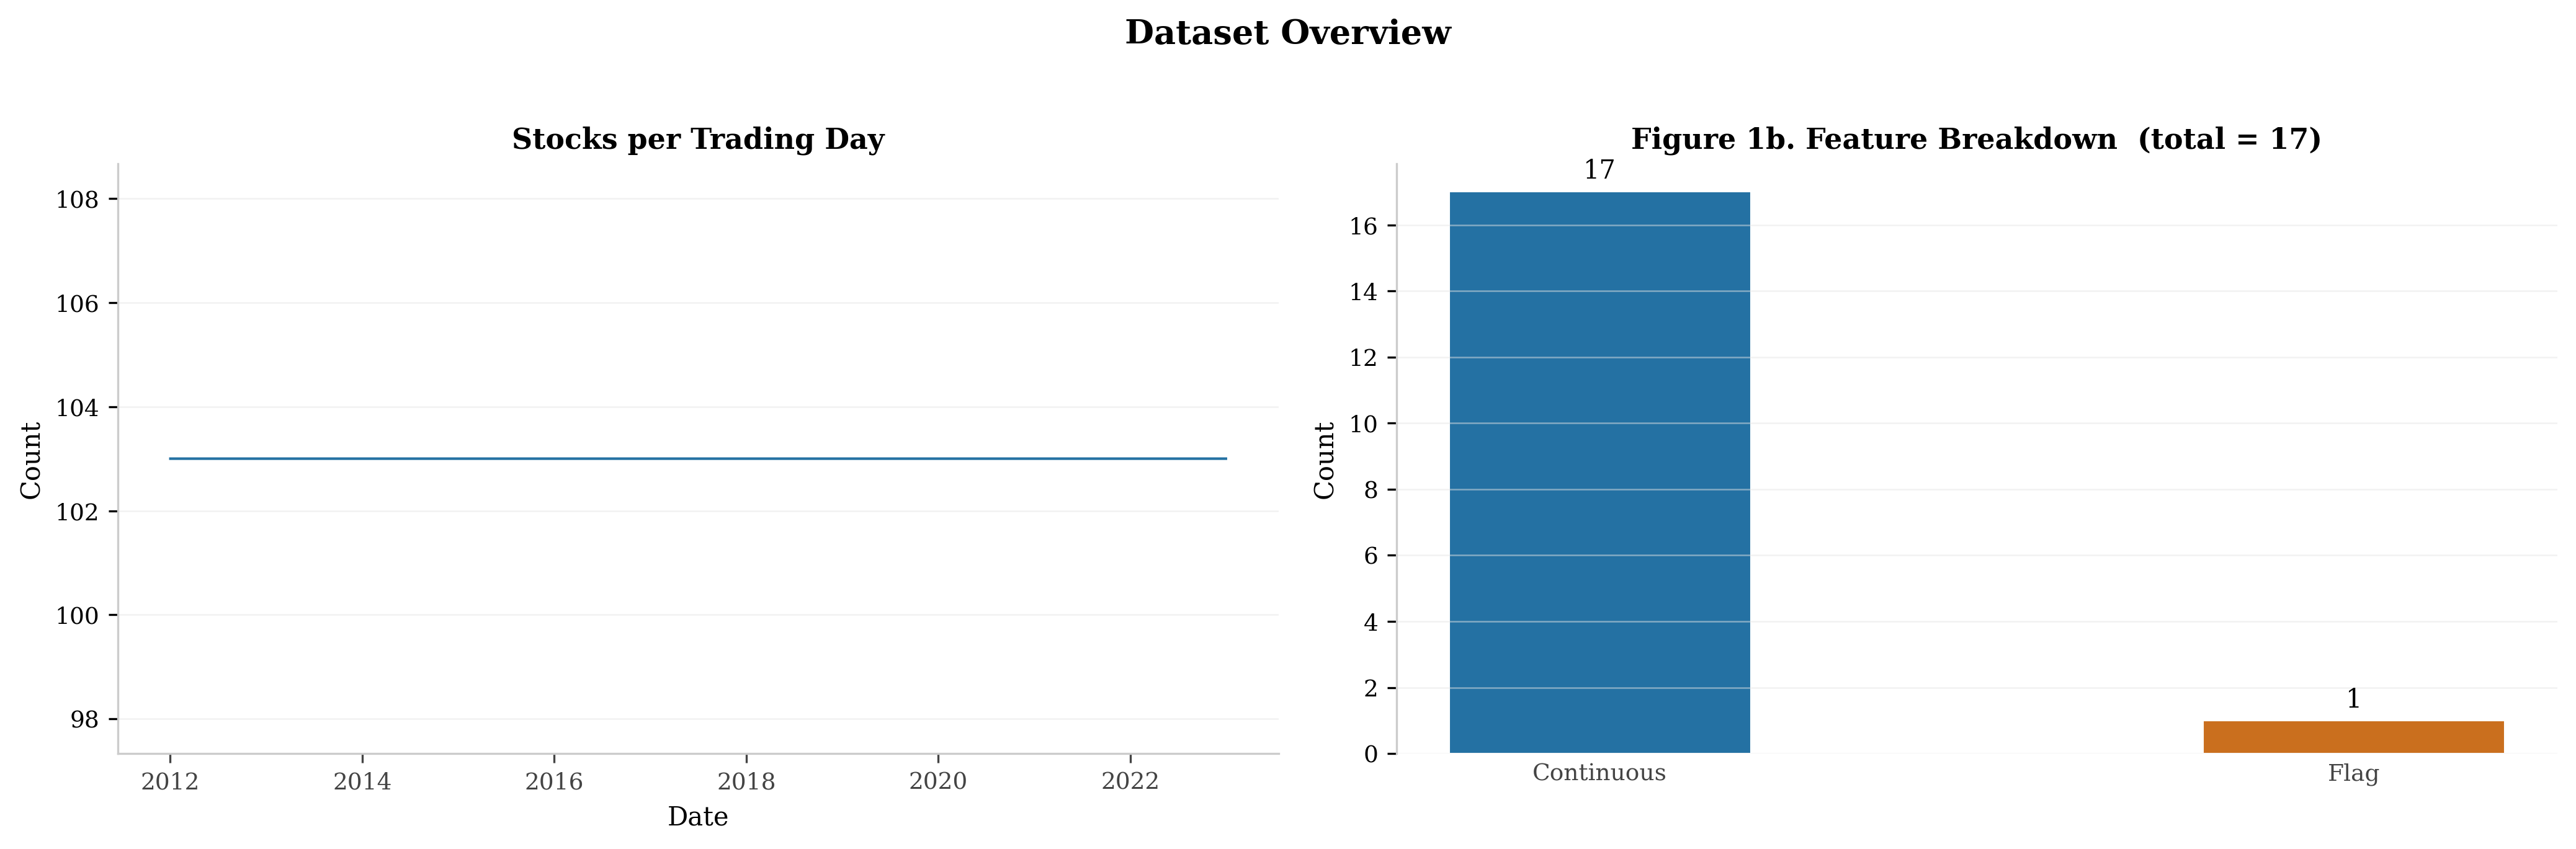

Saved -> fig5_eda_overview.png


In [ ]:
# ── Cell 6.1 : Dataset Overview ───────────────────────────────────────────────
def eda_overview(master_df_full, feature_cols_new, flag_features, cont_features):
    df = master_df_full.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    print("=" * 60)
    print("  DATASET OVERVIEW")
    print("=" * 60)
    print(f"  Shape              : {df.shape}")
    print(f"  Date range         : {df['Date'].min().date()} -> {df['Date'].max().date()}")
    print(f"  Trading days       : {df['Date'].nunique()}")
    print(f"  Stocks             : {df['Symbol'].nunique()}")
    print(f"  Feature cols total : {len(feature_cols_new)}")
    print(f"    Continuous       : {len(cont_features)}")
    print(f"    Flag features    : {len(flag_features)}")
    print(f"  Rows per stock avg : {len(df) / df['Symbol'].nunique():.0f}")

    miss = df[feature_cols_new].isnull().mean()
    print(f"\n  Missing values in features:")
    print(f"    Features with any NaN : {(miss > 0).sum()}  "
          f"{'ok - none' if (miss > 0).sum() == 0 else '<- check Chunk 4'}")

    stocks_per_day = df.groupby("Date")["Symbol"].count()
    print(f"\n  Stocks per trading day:")
    print(f"    Min / Mean / Max : {stocks_per_day.min()} / "
          f"{stocks_per_day.mean():.1f} / {stocks_per_day.max()}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    axes[0].plot(stocks_per_day.index, stocks_per_day.values, color=C_BLUE, lw=1)
    axes[0].set_title("Stocks per Trading Day")
    axes[0].set_ylabel("Count")
    axes[0].set_xlabel("Date")
    axes[0].grid(True, axis="y", alpha=0.5)
    axes[0].grid(False, axis="x")

    # feature type breakdown
    categories = ["Continuous", "Flag"]
    counts     = [len(cont_features), len(flag_features)]
    bars = axes[1].bar(categories, counts, color=[C_BLUE, C_ORANGE],
                       width=0.4, edgecolor="white", linewidth=0.5)
    for bar, cnt in zip(bars, counts):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     cnt + 0.4, str(cnt), ha="center", fontsize=10)
    axes[1].set_title(f"Figure 1b. Feature Breakdown  (total = {len(feature_cols_new)})")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, axis="y", alpha=0.5)
    axes[1].grid(False, axis="x")
    axes[1].spines["bottom"].set_visible(False)
    axes[1].tick_params(axis="x", length=0)

    fig.suptitle("Dataset Overview", fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.savefig("fig5_eda_overview.png", **SAVE_KW)
    plt.show()
    print("Saved -> fig5_eda_overview.png")

# Overview
eda_overview(
    master_df_full  = master_df_full[master_df_full['split']=='train'],
    feature_cols_new = feature_cols_new,
    flag_features   = flag_features,
    cont_features   = cont_features,
)

  TARGET ANALYSIS  —  target_vol_adj  (HORIZON=7d)
  Count            : 279,233
  Mean             : +0.00324
  Median           : +0.00094
  Std              : 0.04564
  Skewness         : 0.164  (0=symmetric)
  Excess Kurtosis  : 4.722  (0=normal, >0=fat tails)
  Min / Max        : -0.2468 / 0.2486
  q10 / q90        : -0.0432 / 0.0530
  % positive       : 51.37%

  Cross-sectional stats (across stocks, per day):
  Avg daily mean    : +0.00324
  Avg daily std     : 0.03863  <- KEY NUMBER
  Avg daily q90-q10 : 0.08281

  Interpretation:
  ok  0.0386 > 0.015 - Good dispersion, ranking is feasible


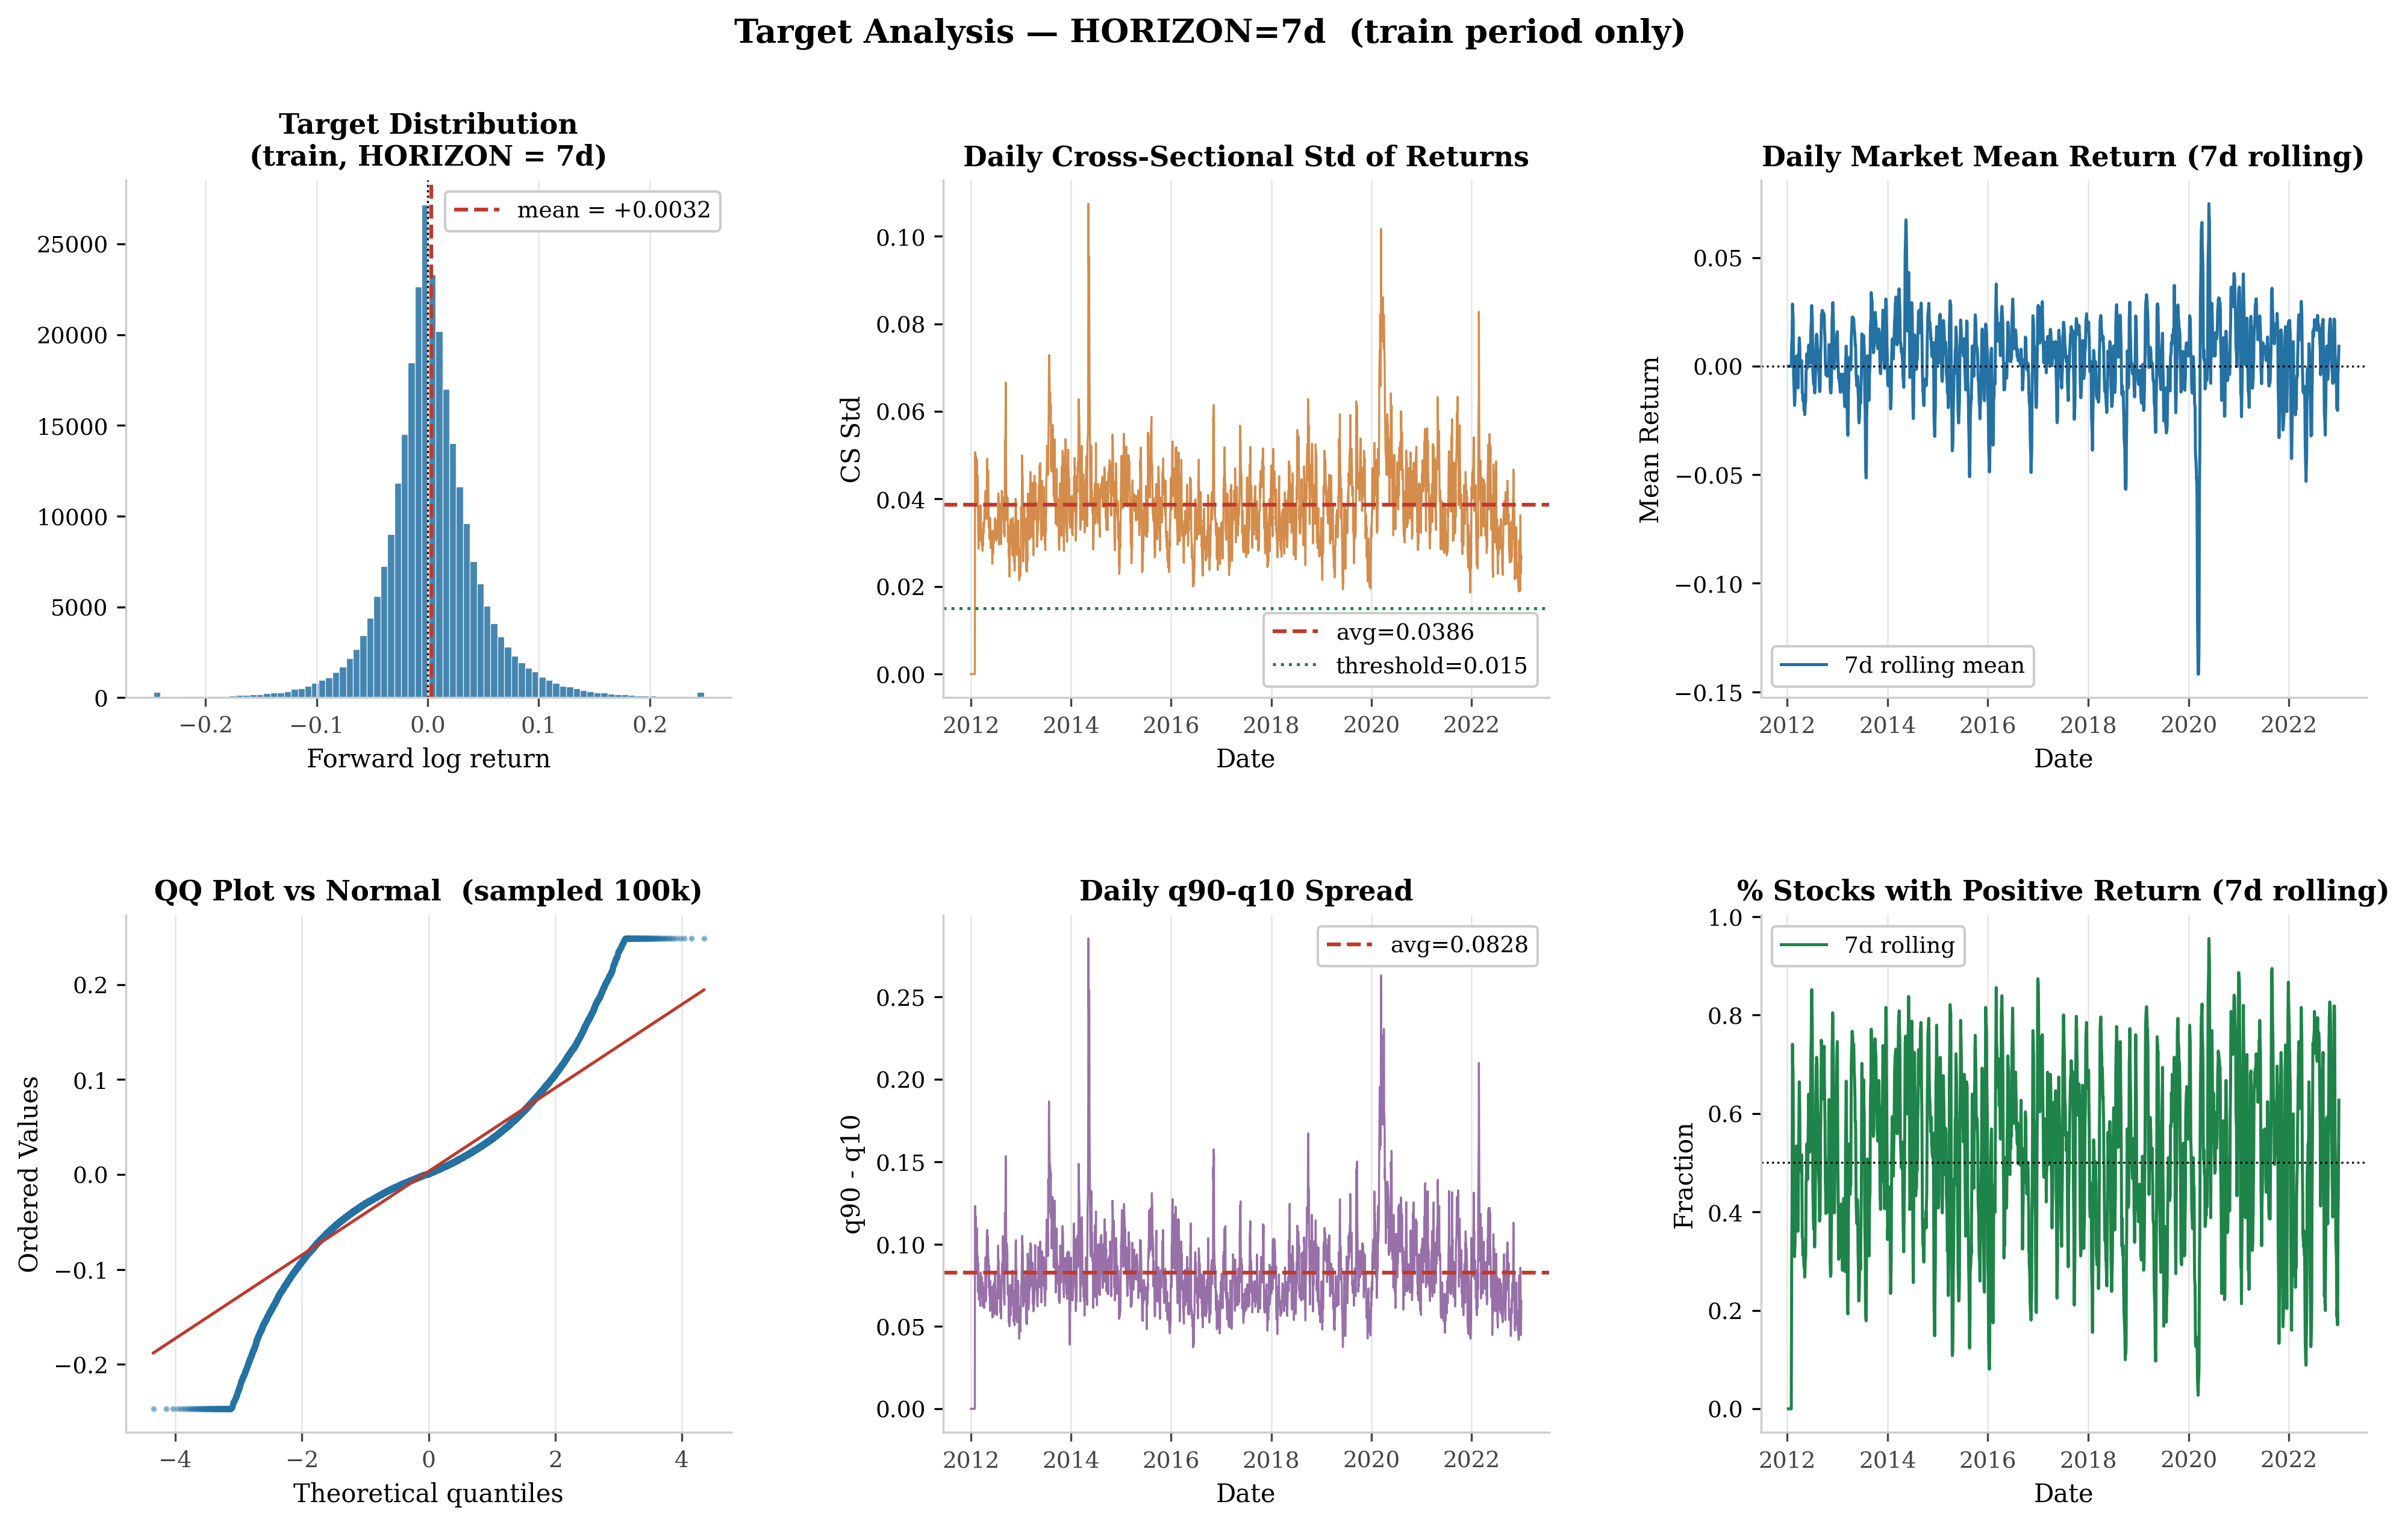

[INFO] Saved -> fig6_eda_target.png


In [ ]:
def eda_target(master_df_full, target_col, horizon,
               train_end, valid_start, valid_end, test_start, test_end):

    df = master_df_full.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    train_df = df[df["Date"] <= pd.to_datetime(train_end)].copy()
    tgt      = train_df[target_col].dropna()

    print("=" * 60)
    print(f"  TARGET ANALYSIS  —  {target_col}  (HORIZON={horizon}d)")
    print("=" * 60)
    print(f"  Count            : {len(tgt):,}")
    print(f"  Mean             : {tgt.mean():+.5f}")
    print(f"  Median           : {tgt.median():+.5f}")
    print(f"  Std              : {tgt.std():.5f}")
    print(f"  Skewness         : {skew(tgt):.3f}  (0=symmetric)")
    print(f"  Excess Kurtosis  : {kurtosis(tgt):.3f}  (0=normal, >0=fat tails)")
    print(f"  Min / Max        : {tgt.min():.4f} / {tgt.max():.4f}")
    print(f"  q10 / q90        : {tgt.quantile(0.1):.4f} / {tgt.quantile(0.9):.4f}")
    print(f"  % positive       : {(tgt > 0).mean():.2%}")

    # cross-sectional stats per day
    cs_stats = train_df.groupby("Date")[target_col].agg(["mean", "std"])
    cs_stats["q90_q10"] = (
        train_df.groupby("Date")[target_col]
        .apply(lambda x: x.quantile(0.9) - x.quantile(0.1))
    )

    print(f"\n  Cross-sectional stats (across stocks, per day):")
    print(f"  Avg daily mean    : {cs_stats['mean'].mean():+.5f}")
    print(f"  Avg daily std     : {cs_stats['std'].mean():.5f}  <- KEY NUMBER")
    print(f"  Avg daily q90-q10 : {cs_stats['q90_q10'].mean():.5f}")

    threshold = 0.015
    cs_std = cs_stats['std'].mean()
    flag = "Good dispersion, ranking is feasible" if cs_std > threshold else "LOW dispersion - ranking may be difficult"
    print(f"\n  Interpretation:")
    print(f"  {'ok' if cs_std > threshold else 'WARNING'}  "
          f"{cs_std:.4f} {'>' if cs_std > threshold else '<='} {threshold} - {flag}")

    fig = plt.figure(figsize=(16, 9))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

    # 1. return distribution
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(tgt, bins=80, color=C_BLUE, alpha=0.85, edgecolor="white", linewidth=0.3)
    ax1.axvline(tgt.mean(), color=C_RED, lw=1.5, linestyle="--",
                label=f"mean = {tgt.mean():+.4f}")
    ax1.axvline(0, color="black", lw=0.8, linestyle=":")
    ax1.set_title(f"Target Distribution\n(train, HORIZON = {horizon}d)")
    ax1.set_xlabel("Forward log return")
    ax1.legend()

    # 2. daily cross-sectional std over time
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(cs_stats.index, cs_stats["std"], color=C_ORANGE, lw=0.8, alpha=0.8)
    ax2.axhline(cs_stats["std"].mean(), color=C_RED, lw=1.5,
                linestyle="--", label=f"avg={cs_stats['std'].mean():.4f}")
    ax2.axhline(threshold, color=C_GREEN, lw=1.2,
                linestyle=":", label=f"threshold={threshold}")
    ax2.set_title("Daily Cross-Sectional Std of Returns")
    ax2.set_ylabel("CS Std")
    ax2.set_xlabel("Date")
    ax2.legend()

    # 3. daily market mean return
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(cs_stats.index, cs_stats["mean"].rolling(7).mean(),
             color=C_BLUE, lw=1.2, label="7d rolling mean")
    ax3.axhline(0, color="black", lw=0.8, linestyle=":")
    ax3.set_title("Daily Market Mean Return (7d rolling)")
    ax3.set_ylabel("Mean Return")
    ax3.set_xlabel("Date")
    ax3.legend()

    # 4. QQ plot
    from scipy import stats as scipy_stats
    ax4 = fig.add_subplot(gs[1, 0])
    scipy_stats.probplot(tgt.sample(min(100000, len(tgt)), random_state=42),
                         dist="norm", plot=ax4)
    ax4.set_title("QQ Plot vs Normal  (sampled 100k)")
    ax4.get_lines()[0].set(color=C_BLUE, markersize=1.5, alpha=0.4)
    ax4.get_lines()[1].set(color=C_RED, lw=1.2)

    # 5. q90-q10 spread over time
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.plot(cs_stats.index, cs_stats["q90_q10"], color=C_PURPLE, lw=0.8, alpha=0.7)
    ax5.axhline(cs_stats["q90_q10"].mean(), color=C_RED, lw=1.5,
                linestyle="--", label=f"avg={cs_stats['q90_q10'].mean():.4f}")
    ax5.set_title("Daily q90-q10 Spread")
    ax5.set_ylabel("q90 - q10")
    ax5.set_xlabel("Date")
    ax5.legend()

    # 6. % positive days over time
    ax6 = fig.add_subplot(gs[1, 2])
    pct_pos = train_df.groupby("Date")[target_col].apply(lambda x: (x > 0).mean())
    ax6.plot(pct_pos.index, pct_pos.rolling(7).mean(),
             color=C_GREEN, lw=1.2, label="7d rolling")
    ax6.axhline(0.5, color="black", lw=0.8, linestyle=":")
    ax6.set_title("% Stocks with Positive Return (7d rolling)")
    ax6.set_ylabel("Fraction")
    ax6.set_xlabel("Date")
    ax6.legend()

    plt.suptitle(f"Target Analysis — HORIZON={horizon}d  (train period only)",
                 fontsize=13, fontweight="bold")
    plt.savefig("fig6_eda_target.png", **SAVE_KW)
    plt.show()
    print("[INFO] Saved -> fig6_eda_target.png")


eda_target(
    master_df_full = master_df_full[master_df_full['split']=='train'],
    target_col     = TARGET_COL,
    horizon        = HORIZON,
    train_end      = TRAIN_END,
    valid_start    = VALID_START,
    valid_end      = VALID_END,
    test_start     = TEST_START,
    test_end       = TEST_END,
)

In [ ]:
###
###
"""
Here three major changes
1. Less Features
2. Target is vol adjusted returns
3. Clipping is after calcualtion of new target and only as per training data
4. Quantiles are 10-90 %
"""

'\nHere three major changes\n1. Less Features\n2. Target is vol adjusted returns\n3. Clipping is after calcualtion of new target and only as per training data\n4. Quantiles are 10-90 %\n'

In [ ]:
# Uploading Data outputs to GCS
# Step 1 Directory for H1

# DIR = f"centralefs/modelfiles/h{HORIZON}"
# DIR = f"centralefs/modelfiles/pfeats7u"
# centralefs/modelfiles/pfeats7u

print("\n Uploading Data to GCS...")
!gsutil -m cp fig5_eda_overview.png   gs://{DIR}/step1/
!gsutil -m cp fig6_eda_target.png   gs://{DIR}/step1/

# !gsutil -m cp master_df_full_1D.parquet gs://{DIR}/step1/
# !gsutil cp    master_df_full_pruned_without_na_d61.parquet gs://{DIR}/step1/ 2>/dev/null || true

print("Plots uploaded")


 Uploading Data to GCS...
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://fig5_eda_overview.png [Content-Type=image/png]...
/ [1/1 files][112.8 KiB/112.8 KiB] 100% Done                                    
Operation completed over 1 objects/112.8 KiB.                                    
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://fig6_eda_target.png [Content-Type=image/png]...
/ [1/1 files][790.7 KiB/790.7 KiB] 100% Done                                    
Operation completed over 1 objects/790.7 KiB.                                    
P